In [1]:
# conda activate meteor
# rm -r venv              
# make first-venv
# make clean
# make virtual-environment
# source venv/bin/activate
# then select the kernel 'venv' in jupyter notebook

import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from dataclasses import asdict
import warnings
from pandas.errors import SettingWithCopyWarning
from functools import partial
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings("ignore", message=".*not in pamset.*")

from meteor import MeteorPatternScaling, meteor_plot_utils
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
from meteor import scm_forcer_engine
from ciceroscm import CICEROSCM
from ciceroscm import input_handler

from meteor.prpatt import global_mean
from meteor.prpatt import recon

import cartopy.crs as ccrs
import cartopy as cart
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata
import matplotlib.ticker as mticker
from scipy.stats import pearsonr
from tqdm import tqdm

In [2]:
## NBVAL_IGNORE_OUTPUT
#sys.path.insert(0,os.path.join(os.getcwd(), '../'))
#module_path = os.path.abspath(os.path.join('../src'))
#if module_path not in sys.path:
#    sys.path.append(module_path)

#cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

In [2]:
savecache=0

cachedir = os.path.join(os.getcwd(), "cache")
if not os.path.exists(cachedir):
        os.makedirs(cachedir)
        
figdir = os.path.join(os.getcwd(), "figures")
if not os.path.exists(figdir):
        os.makedirs(figdir)

cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

# Data preparations

### Getting some data that can be used by the forcer engine and ciceroscm

SSP245 for aerorol residual from abrupt-4xCO2

In [3]:
%%capture
ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

#For predictions: 
conc_data = input_handler.read_inputfile(os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt"))
em_data = ih.read_emissions(os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt"))

standard SSP scenarios

In [4]:
scenarios = [ "ssp126", "ssp245", "ssp370", "ssp585"]

In [5]:
%%capture
#For predictions: read in SSP concentrations and emissions
#scenarios = ["ssp126","ssp245","ssp370","ssp585"]

ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

conc_data_fwd=[]
em_data_fwd=[]
for i,s in enumerate(scenarios):
    conc_data_fwd.append(input_handler.read_inputfile(os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")))
    em_data_fwd.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

SSP534-over

In [6]:
%%capture
#For predictions: read in SSP concentrations and emissions

ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

conc_data_ssp534=[]
em_data_ssp534=[]
for i,s in enumerate(['ssp534-over']):
    conc_data_ssp534.append(input_handler.read_inputfile(os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")))
    em_data_ssp534.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

### Getting data for standard scenarios

Getting CMIP6 data from the zarrstore for tas

In [7]:
flds = ["tas","pr"]
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp126", "ssp245", "ssp370", "ssp585"], 
                                    flds = flds, 
                                    dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP', 'ScenarioMIP','ScenarioMIP', 'ScenarioMIP'])

#for property, value in vars(data_getter).items():
#    print(property)

In [8]:
models = data_getter.models
len(models)

35

Create training data dictionary for all selected models (may run for a while) - and save locally in 'cache' (cachedir) due to data memory requirements

In [9]:
if savecache:
    #training_data_dict = {}
    for nm,mname in enumerate(models):
        print(nm, mname)

        # create model-specific training data
        #training_data_dict[mname] = {
        training_data = {
            "base": data_getter.make_meteor_training_data("base", mname),
            "co2x4": data_getter.make_meteor_training_data("co2x4", mname),
            "sulxanom": data_getter.make_meteor_training_data_composite(["historical", "ssp245"], mname),
        }

        for s in scenarios:
                training_data[s]=data_getter.make_meteor_training_data_composite(
                        ["historical", s], mname
                    )

        # save data locally (cache) to avoid running this cell again and again when accessing data
        for k in training_data:
            training_data[k].to_netcdf(os.path.join(cachedir, f"{mname}_{k}_training_data.nc"))

Load locally saved training data

In [10]:
# remove problematic models when creating the pattern
if 'IITM-ESM' in models: models.pop(models.index('IITM-ESM'))  # drop because bad data
if 'IPSL-CM6A-LR' in models: models.pop(models.index('IPSL-CM6A-LR'))  # drop because of data issue
if 'TaiESM1' in models: models.pop(models.index('TaiESM1'))  # drop because of data issue
if 'EC-Earth3' in models: models.pop(models.index('EC-Earth3'))  # drop because of data issue in pr
if 'GISS-E2-1-G' in models: models.pop(models.index('GISS-E2-1-G'))  # drop temperature fit doesn't work
##if 'MRI-ESM2-0' in models: models.pop(models.index('MRI-ESM2-0'))

In [11]:
training_data_dict={}
for nm,mname in enumerate(models):
    #print(nm,mname)

    training_data_dict[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")),
        "ssp126": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp126_training_data.nc")),
        "ssp245": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp245_training_data.nc")),
        "ssp370": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp370_training_data.nc")),
        "ssp585": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp585_training_data.nc")),
    }

### Getting data for SSP534-over

In [12]:
data_getter_ssp534 = Cmip6MeteorDataGetter(exps=["piControl", "historical", "ssp534-over"], 
                                    flds = flds, 
                                    dbe=['CMIP','CMIP', 'ScenarioMIP'])

models_ssp534 = data_getter_ssp534.models
len(models_ssp534)

12

In [13]:
# save data to cache (if indicated)
# may need to read in 'base' (piControl) experiemnt data if not done with standard SSPs (or if there is a model missing)
if savecache:
    for nm,mname in enumerate(models_ssp534):
        print(nm, mname)

        # create model-specific training data
        training_data = {
            #"base": data_getter_ssp534.make_meteor_training_data("base", mname),
            "ssp534-over": data_getter_ssp534.make_meteor_training_data_composite(["historical", "ssp585", "ssp534-over"], mname, overlap={"ssp534-over": "Full-back"}),
        }

        # save data locally (cache) to avoid running this cell again and again when accessing data
        for k in training_data:
            training_data[k].to_netcdf(os.path.join(cachedir, f"{mname}_{k}_training_data.nc"))

In [14]:
if 'EC-Earth3' in models_ssp534: models_ssp534.pop(models_ssp534.index('EC-Earth3'))  # drop because of data issue in pr
if 'IPSL-CM6A-LR' in models_ssp534: models_ssp534.pop(models_ssp534.index('IPSL-CM6A-LR'))  # drop because of data issue

In [15]:
# load locally saved training data
training_data_dict_ssp534={}
for nm,mname in enumerate(models_ssp534):
    #print(nm,mname)

    training_data_dict_ssp534[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")),
        "ssp534-over": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp534-over_training_data.nc")),
    }

In [147]:
training_data_dict_ssp534['CanESM5']['ssp534-over']['tas'].shape

(1, 226, 64, 128)

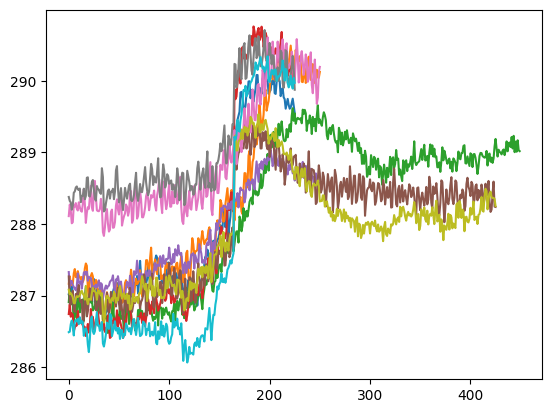

In [154]:
for nm,mname in enumerate(models_ssp534):
    plt.plot(global_mean(training_data_dict_ssp534[mname]['ssp534-over']['tas']).values[0,:])

# Create GHG modes and patterns for all selected models

In [16]:
%%capture

CMIP_pattern_dict = {}
for nm,mname in enumerate(models):

    # create GHG modes and spatial pattern
    CMIP_pattern_dict[mname] = MeteorPatternScaling(
            mname,
            {"tas": 3, "pr": 3},
            lambda key: training_data_dict[mname][key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
            anom_timescales={"tas": 3, "pr": 3}
        )


# GHG patterns

timescales

In [17]:
t1_ghg = np.zeros([len(flds),len(models)])
t2_ghg = np.zeros([len(flds),len(models)])
t3_ghg = np.zeros([len(flds),len(models)])
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        t1_ghg[nv,nm] = CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]['outp']['t0'].value
        t2_ghg[nv,nm] = CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]['outp']['t1'].value
        t3_ghg[nv,nm] = CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]['outp']['t2'].value

Plot single GHG model responses (tas + pr)

In [22]:
%%capture

vmins = [-3,-15]
vmaxs = [3,15]
cmaps = ["RdBu_r","BrBG"]

# prepare figure canvas
fig = plt.figure(figsize=(20,len(models)*2.5))
gs = GridSpec(len(models), 4, figure=fig)
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):

        # create figure row by row
        sub = fig.add_subplot(gs[nm, 0])
        sub.set_xlabel("Years")
        sub.set_ylabel("$\Delta$"+var)
        sub.plot(global_mean(CMIP_pattern_dict[mname].dacanom[var][CMIP_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :]), color="gray", label="Original data")
        sub.plot(global_mean(recon(CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full'])), color="tab:orange", label="Reconstruction")
        sub.legend(frameon=False)
        sub.annotate(mname, xy=(0.02, 0.92), xycoords='axes fraction', fontsize=10, ha='left', va='center', weight="bold")

        sub = fig.add_subplot(gs[nm, 1])  #,projection=ccrs.PlateCarree())   #sub.coastlines()
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat, 
                            CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])   # ,transform=cart.crs.PlateCarree()

        sub = fig.add_subplot(gs[nm, 2])
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat,
                            CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][1, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])

        sub = fig.add_subplot(gs[nm, 3])
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat,
                            CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][2, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])
        
    plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_"+var+".jpg"), bbox_inches='tight')

GHG multi-model composite

In [62]:
### global mean timeseriess
CMIP_GHG_gm_response_co2x4 = np.zeros([len(flds),len(models),100]) * np.nan
CMIP_GHG_gm_response_recon_co2x4 = np.zeros([len(flds),len(models),100]) * np.nan
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        CMIP_GHG_gm_response_co2x4[nv,nm,:] = global_mean(CMIP_pattern_dict[mname].dacanom[var][CMIP_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :])
        CMIP_GHG_gm_response_recon_co2x4[nv,nm,:] = global_mean(recon(CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full']))

In [70]:
# interpolate gridded data to common grid

target_model_grid = 'ACCESS-CM2'

# Define (new) common grid
common_lons = CMIP_pattern_dict[target_model_grid].pattern_dict['co2x4']['tas']["pattern_full"]["v"][0, :, :].lon  # Adjust the number of points as needed
common_lats = CMIP_pattern_dict[target_model_grid].pattern_dict['co2x4']['tas']["pattern_full"]["v"][0, :, :].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

# Interpolate to native grid and data
common_grid_ghg_data_T1 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
common_grid_ghg_data_T2 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
common_grid_ghg_data_T3 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
total_iterations = len(flds) * len(models)
with tqdm(total=total_iterations) as pbar:
    for nv,var in enumerate(flds):
        for nm,mname in enumerate(models):
            native_data_T1 = CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :]
            native_data_T2 = CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][1, :, :]
            native_data_T3 = CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][2, :, :]
            native_lons = CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon
            native_lats = CMIP_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat
            native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            # Interpolate
            common_grid_ghg_data_T1[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                                np.array(native_data_T1).flatten(), 
                                                (common_lon_grid, common_lat_grid), method='cubic')
            common_grid_ghg_data_T2[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                                np.array(native_data_T2).flatten(), 
                                                (common_lon_grid, common_lat_grid), method='cubic')
            common_grid_ghg_data_T3[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                                np.array(native_data_T3).flatten(), 
                                                (common_lon_grid, common_lat_grid), method='cubic')
            
            pbar.update(1)

100%|██████████| 60/60 [01:02<00:00,  1.04s/it]


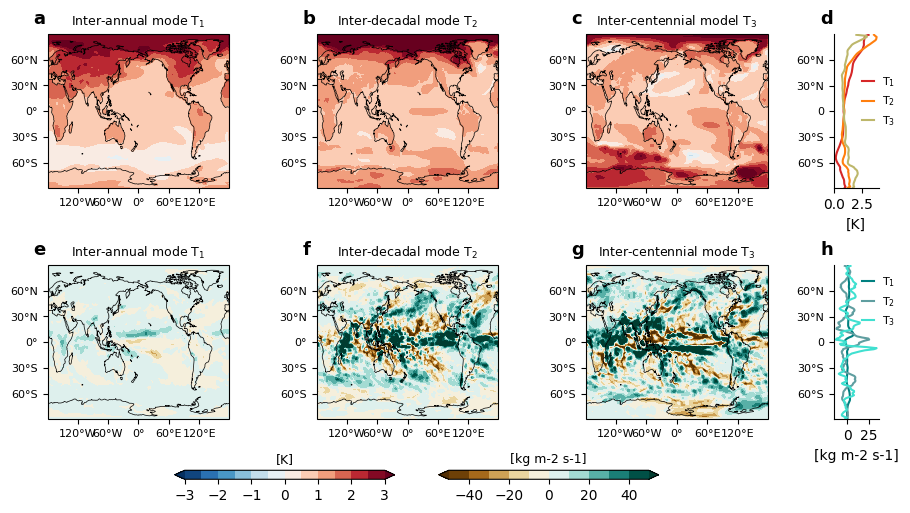

In [41]:
levels = [np.arange(-3,3.1,0.5), np.arange(-50,51,10)]
units = ["[K]","[kg m-2 s-1]"]
titles = ["$\Delta$GMST [K]", "$\Delta$GMP [kg m-2 s-1]"]
cmaps = ["RdBu_r","BrBG"]

nrows = 2
ncols = 10
X = [ (1,3), (4,6), (7,9), (10),
      (11,13), (14,16), (17,19), (20)]

fig = plt.figure(figsize=(11,5))

# ---------- subfig 1
#sub = fig.add_subplot(2, ncols, X[0])
#sub.set_xlim(0,11)
#sub.set_ylim(0,110)
#sub.set_xticks([0,2,4,6,8,10])
#sub.set_xticklabels([0,2,4,6,8,10])
##sub.scatter(t1_ghg, t2_ghg, color="tab:red", edgecolor="black")
#sub.scatter(t1_ghg[0,:][(t1_ghg[0,:] < 9) | (t2_ghg[0,:] < 99)],
#            t2_ghg[0,:][(t1_ghg[0,:] < 9) | (t2_ghg[0,:] < 99)], color="tab:red", edgecolor="black")
#sub.scatter(t1_ghg[0,:][(t1_ghg[0,:] > 9) | (t2_ghg[0,:] > 99)],
#            t2_ghg[0,:][(t1_ghg[0,:] > 9) | (t2_ghg[0,:] > 99)], color="gray", edgecolor="black")
#sub.axhline(100, color="black", lw=0.5, linestyle="--")
#sub.axvline(10, color="black", lw=0.5, linestyle="--")
#sub.annotate('a', xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# ---------- subfig 1
sub = fig.add_subplot(2, ncols, X[0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
sub.set_title("Inter-annual mode T$_1$", size=9)
cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_ghg_data_T1[0,:,:,:],0), cmap=cmaps[0], levels=levels[0], extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.7)
sub.annotate('a', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# ---------- subfig 2
sub = fig.add_subplot(2, ncols, X[1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
sub.set_title("Inter-decadal mode T$_2$", size=9)
cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_ghg_data_T2[0,:,:,:],0), cmap=cmaps[0], levels=levels[0], extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.7)
sub.annotate('b', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# external colorbar
cbar = fig.add_axes([0.26, -0.01, 0.2, 0.018])
fig.colorbar(cont, cax=cbar, orientation='horizontal')
cbar.set_title(units[0], size=9, pad=5, ha="center")

# ---------- subfig 3
sub = fig.add_subplot(2, ncols, X[2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
sub.set_title("Inter-centennial model T$_3$", size=9)
cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_ghg_data_T3[0,:,:,:],0), cmap=cmaps[0], levels=levels[0], extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.7)
sub.annotate('c', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# ---------- subfig 4
sub = fig.add_subplot(2, ncols, X[3])
sub.spines[['right', 'top']].set_visible(False)
sub.set_xlabel(units[0])
sub.set_ylim(-90,90)
sub.set_yticks(np.arange(-60, 61, 30))
sub.set_yticklabels(["60°S","30°S","0","30°N","60°N"], size=8)
sub.plot(np.nanmean(common_grid_ghg_data_T1[0,:,:,:],(0,2)), common_lats, color="tab:red", label="T$_1$")
sub.plot(np.nanmean(common_grid_ghg_data_T2[0,:,:,:],(0,2)), common_lats, color="tab:orange", label="T$_2$")
sub.plot(np.nanmean(common_grid_ghg_data_T3[0,:,:,:],(0,2)), common_lats, color="darkkhaki", label="T$_3$")
sub.legend(frameon=False, loc="upper right", prop={'size': 8}, bbox_to_anchor=(1.6,0.8), handlelength=1)
sub.annotate('d', xy=(-0.30, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# ---------- 
# ---------- subfig 5
# sub = fig.add_subplot(2, ncols, X[4])
# sub.set_xlim(0,11)
# sub.set_ylim(0,110)
# sub.set_xticks([0,2,4,6,8,10])
# sub.set_xticklabels([0,2,4,6,8,10])
# #sub.scatter(t1_ghg[1,:], t2_ghg[1,:], color="teal", edgecolor="black")
# sub.scatter(t1_ghg[1,:][(t1_ghg[1,:] < 9) | (t2_ghg[1,:] < 99)],
#             t2_ghg[1,:][(t1_ghg[1,:] < 9) | (t2_ghg[1,:] < 99)], color="teal", edgecolor="black")
# sub.scatter(t1_ghg[1,:][(t1_ghg[1,:] > 9) | (t2_ghg[1,:] > 99)],
#             t2_ghg[1,:][(t1_ghg[1,:] > 9) | (t2_ghg[1,:] > 99)], color="gray", edgecolor="black")
# sub.axhline(100, color="black", lw=0.5, linestyle="--")
# sub.axvline(10, color="black", lw=0.5, linestyle="--")
# sub.annotate('e', xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# ---------- subfig 5
sub = fig.add_subplot(2, ncols, X[4], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
sub.set_title("Inter-annual mode T$_1$", size=9)
cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_ghg_data_T1[1,:,:,:],0), cmap=cmaps[1], levels=levels[1], extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.7)
sub.annotate('e', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# ---------- subfig 6
sub = fig.add_subplot(2, ncols, X[5], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
sub.set_title("Inter-decadal mode T$_2$", size=9)
cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_ghg_data_T2[1,:,:,:],0), cmap=cmaps[1], levels=levels[1], extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.7)
sub.annotate('f', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# external colorbar
cbar = fig.add_axes([0.50, -0.01, 0.2, 0.018])
fig.colorbar(cont, cax=cbar, orientation='horizontal')
cbar.set_title(units[1], size=9, pad=5, ha="center")

# ---------- subfig 7
sub = fig.add_subplot(2, ncols, X[6], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
sub.set_title("Inter-centennial mode T$_3$", size=9)
cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_ghg_data_T3[1,:,:,:],0), cmap=cmaps[1], levels=levels[1], extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.7)
sub.annotate('g', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# ---------- subfig 8
sub = fig.add_subplot(2, ncols, X[7])
sub.spines[['right', 'top']].set_visible(False)
sub.set_xlabel(units[1])
sub.set_ylim(-90,90)
sub.set_yticks(np.arange(-60, 61, 30))
sub.set_yticklabels(["60°S","30°S","0","30°N","60°N"], size=8)
sub.plot(np.nanmean(common_grid_ghg_data_T1[1,:,:,:],(0,2)), common_lats, color="teal", label="T$_1$")
sub.plot(np.nanmean(common_grid_ghg_data_T2[1,:,:,:],(0,2)), common_lats, color="cadetblue", label="T$_2$")
sub.plot(np.nanmean(common_grid_ghg_data_T3[1,:,:,:],(0,2)), common_lats, color="turquoise", label="T$_3$")
sub.legend(frameon=False, loc="upper right", prop={'size': 8}, bbox_to_anchor=(1.6,1), handlelength=1)
sub.annotate('h', xy=(-0.30, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=1, hspace=0.5)
plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_composite.pdf"), bbox_inches='tight')

Taking ssp-data for ciceroscm and make GHG-only predictions (for abrupt-4xCO2)

In [43]:
%%capture

### using dirctionary is too memeory intensive
#patterns_ghg={}
#for nm,mname in enumerate(models):
#    patterns_ghg[mname] = CMIP_pattern_dict[mname].predict_from_combined_experiment(
#            em_data, conc_data, ["pr", "tas"],
#            return_patterns_per_mode=True
#    )

#patterns_ghg = np.zeros([len(flds),len(models),6,351]) * np.nan
#for nv,var in enumerate(flds):
#    for nm,mname in enumerate(models):
#        for mode in np.arange(0,6):
#                patterns_ghg[nv,nm,mode,:] = global_mean(CMIP_pattern_dict[mname].predict_from_combined_experiment(
#                        em_data, conc_data, [var],
#                        return_patterns_per_mode=True
#                )[var][mode,:,:,:])

Taking ssp-data for ciceroscm and make GHG-only predictions (foward modelling with out-of-sample scenarios)

In [27]:
%%capture
# Standard SSPs
# use np.array instead of dictionary because the 6D data array with many models causes memory problems for the notebook

#patterns_ghg_ssp={}
#for nm,mname in enumerate(models):
#    patterns_ghg_ssp[mname]={}

#    for nsc,sc in enumerate(scenarios):
#            patterns_ghg_ssp[mname][sc] = CMIP_pattern_dict[mname].predict_from_combined_experiment(
#                    em_data_fwd[nsc], conc_data_fwd[nsc], ["pr", "tas"],
#                    return_patterns_per_mode=True
#            )

#patterns_ghg_ssp=np.zeros([len(models),len(scenarios),len(flds),351])
#for nv,var in enumerate(flds):
#        for nm,mname in enumerate(models):
#                for nsc,sc in enumerate(scenarios):
#                        patterns_ghg_ssp[nm,nsc,nv,:] = global_mean(CMIP_pattern_dict[mname].predict_from_combined_experiment(
#                                em_data_fwd[nsc], conc_data_fwd[nsc], [var],
#                                return_patterns_per_mode=True
#                        )[var])

In [17]:
# save GHG datasaet for later use (assign here before dict is getting deleted)
CMIP_ghg_pattern_dict_gm = np.zeros([len(models),len(flds),100])
for nm,mname in enumerate(models):
    CMIP_ghg_pattern_dict_gm[nm,0,:] = global_mean(CMIP_pattern_dict[mname].dacanom['tas'][CMIP_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :])
    CMIP_ghg_pattern_dict_gm[nm,1,:] = global_mean(CMIP_pattern_dict[mname].dacanom['pr'][CMIP_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :])

In [29]:
# delete here to make 'space' for aerosol pattern dictionary
#del(CMIP_ghg_pattern_dict)

# Aerosol patterns

In [13]:
%%capture

#CMIP_pattern_dict = {}
#CMIP_pattern_dict = {}
# for nm,mname in enumerate(models):

#     # create GHG modes and spatial pattern
#     CMIP_pattern_dict[mname] = MeteorPatternScaling(
#             mname,
#             {"tas": 3, "pr": 3},
#             lambda key: training_data_dict[mname][key],
#             from_file=False,
#             exp_list=["base", "co2x4", "sulxanom"],
#             anom_timescales={"tas": 3, "pr": 3}
#         )

timescales

In [18]:
t1_aer = np.zeros([len(flds),len(models)])
t2_aer = np.zeros([len(flds),len(models)])
t3_aer = np.zeros([len(flds),len(models)])
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        t1_aer[nv,nm] = CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]['outp']['t0'].value
        t2_aer[nv,nm] = CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]['outp']['t1'].value
        t3_aer[nv,nm] = CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]['outp']['t2'].value

Taking ssp-data for ciceroscm and make GHG+aer predictions (for abrupt-4xCO2)

In [17]:
%%capture

### using dirctionary is too memeory intensive
#patterns_gm={}
#for nm,mname in enumerate(models):
#    patterns_gm[mname] = CMIP_pattern_dict[mname].predict_from_combined_experiment(
#            em_data, conc_data, ["pr", "tas"],
#            return_patterns_per_mode=True
#    )

patterns_gm = np.zeros([len(flds),len(models),6,351]) * np.nan
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for mode in np.arange(0,6):
            patterns_gm[nv,nm,mode,:] = global_mean(CMIP_pattern_dict[mname].predict_from_combined_experiment(
                em_data, conc_data, [var],
                return_patterns_per_mode=True
            )[var][mode,:,:,:])

Taking ssp-data for ciceroscm and make GHG+aer predictions (foward modelling with out-of-sample scenarios)

In [18]:
%%capture
# Standard SSPs
# use np.array instead of dictionary because the 6D data array with many models causes memory problems for the notebook

#patterns_aer_ssp={}
#for nm,mname in enumerate(models):
#    patterns_aer_ssp[mname]={}

#    for nsc,sc in enumerate(scenarios):
#        patterns_aer_ssp[mname][sc] = CMIP_aer_pattern.predict_from_combined_experiment(
#                em_data_fwd[nsc], conc_data_fwd[nsc], ["pr", "tas"],
#                return_patterns_per_mode=True
#        )

patterns_gm_ssp = np.zeros([len(flds),len(models),6,len(scenarios),351]) * np.nan
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for mode in np.arange(0,6):
            for nsc,sc in enumerate(scenarios):
                patterns_gm_ssp[nv,nm,mode,nsc,:] = global_mean(CMIP_pattern_dict[mname].predict_from_combined_experiment(
                    em_data_fwd[nsc], conc_data_fwd[nsc], [var],
                    return_patterns_per_mode=True
            )[var][mode,:,:,:])

Plot single aerosol models responses (tas+pr)

In [23]:
%%capture

vmins = [-6,-1e-5]
vmaxs = [6,1e-5]
cmaps = ["RdBu_r","BrBG"]

# prepare figure canvas
fig = plt.figure(figsize=(20,len(models)*2.5))
gs = GridSpec(len(models), 4, figure=fig)
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):

        # create figure row by row
        sub = fig.add_subplot(gs[nm, 0])
        sub.set_xlabel("Years")
        sub.set_ylabel("$\Delta$"+var)
        sub.plot(np.arange(1850,2101), global_mean(CMIP_pattern_dict[mname].dacanom[var][CMIP_pattern_dict[mname].exp_list.index('sulxanom'), :251, :, :]), color="gray", label="Original data")
        #sub.plot(np.arange(1850,2101), global_mean(patterns_gm[mname][var]).values[100:], color="tab:purple", lw=2.5, label="Reconstruction GHG+aer")
        sub.plot(np.arange(1850,2101), np.sum(patterns_gm[nv,nm,:,100:],0), color="tab:purple", lw=2.5, label="Reconstruction GHG+aer")
        sub.legend(frameon=False, loc='upper left', bbox_to_anchor=[0,0.9])
        sub.annotate(mname, xy=(0.02, 0.92), xycoords='axes fraction', fontsize=10, ha='left', va='center', weight="bold")

        sub = fig.add_subplot(gs[nm, 1])  #,projection=ccrs.PlateCarree())   #sub.coastlines()
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lat, 
                            CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])   # ,transform=cart.crs.PlateCarree()

        sub = fig.add_subplot(gs[nm, 2])
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lat,
                            CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][1, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])

        sub = fig.add_subplot(gs[nm, 3])
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lat,
                            CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][2, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])
        
    plt.savefig(os.path.join(figdir, "CMIP_aer_pattern_"+var+".jpg"), bbox_inches='tight')

Aerosol multi-model composite

In [24]:
### global mean timeseries
CMIP_aer_gm_response_sulxanom = np.zeros([len(flds),len(models),251]) * np.nan
CMIP_aer_gm_response_recon_ghgonly = np.zeros([len(flds),len(models),251]) * np.nan
CMIP_aer_gm_response_recon_sulxanom = np.zeros([len(flds),len(models),251]) * np.nan
total_iterations = len(flds) * len(models)
with tqdm(total=total_iterations) as pbar:
    for nv,var in enumerate(flds):
        for nm,mname in enumerate(models):
            CMIP_aer_gm_response_sulxanom[nv,nm,:] = global_mean(CMIP_pattern_dict[mname].dacanom[var][CMIP_pattern_dict[mname].exp_list.index('sulxanom'), :251, :, :])
            #CMIP_aer_gm_response_recon_ghgonly[nv,nm,:] = global_mean(patterns_ghg[mname][var]).values[100:]
            CMIP_aer_gm_response_recon_ghgonly[nv,nm,:] = np.sum(patterns_gm[nv,nm,0:3,100:],0)                      # only GHG modes
            #CMIP_aer_gm_response_recon_sulxanom[nv,nm,:] = global_mean(patterns_anomsulf[mname][var]).values[100:]
            CMIP_aer_gm_response_recon_sulxanom[nv,nm,:] = np.sum(patterns_gm[nv,nm,:,100:],0)
            pbar.update(1)


100%|██████████| 60/60 [00:02<00:00, 27.49it/s]


In [25]:
# interpolate gridded data to common grid

target_model_grid = 'ACCESS-CM2'

# Define (new) common grid
common_lons = CMIP_pattern_dict[target_model_grid].pattern_dict['sulxanom']['tas']["pattern_full"]["v"][0, :, :].lon  # Adjust the number of points as needed
common_lats = CMIP_pattern_dict[target_model_grid].pattern_dict['sulxanom']['tas']["pattern_full"]["v"][0, :, :].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

# Interpolate to native grid and data
common_grid_aer_data_T1 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
common_grid_aer_data_T2 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
common_grid_aer_data_T3 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
total_iterations = len(flds) * len(models)
with tqdm(total=total_iterations) as pbar:
    for nv,var in enumerate(flds):
        for nm,mname in enumerate(models):
            native_data_T1 = CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :]
            native_data_T2 = CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][1, :, :]
            native_data_T3 = CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][2, :, :]
            native_lons = CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lon
            native_lats = CMIP_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lat
            native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)

            # Interpolate
            common_grid_aer_data_T1[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                                np.array(native_data_T1).flatten(), 
                                                (common_lon_grid, common_lat_grid), method='cubic')
            common_grid_aer_data_T2[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                                np.array(native_data_T2).flatten(), 
                                                (common_lon_grid, common_lat_grid), method='cubic')
            common_grid_aer_data_T3[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                                np.array(native_data_T3).flatten(), 
                                                (common_lon_grid, common_lat_grid), method='cubic')
            
            pbar.update(1)

100%|██████████| 60/60 [01:04<00:00,  1.08s/it]


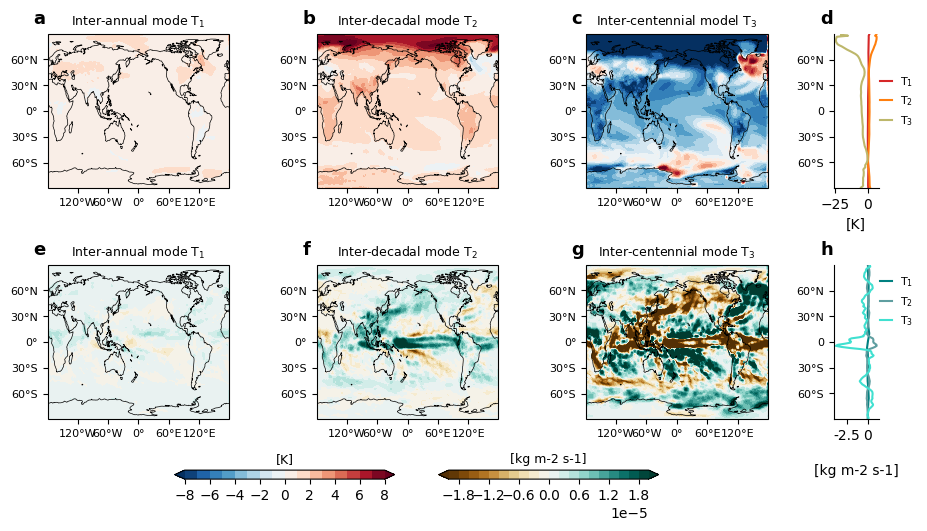

In [47]:
levels = [np.arange(-8,8.1,1), np.arange(-2e-5,2.1e-5,0.2e-5)]
units = ["[K]","[kg m-2 s-1]"]
titles = ["$\Delta$GMST [K]", "$\Delta$GMP [kg m-2 s-1]"]
cmaps = ["RdBu_r","BrBG"]

nrows = 2
ncols = 10
X = [ (1,3), (4,6), (7,9), (10),
      (11,13), (14,16), (17,19), (20)]

fig = plt.figure(figsize=(11,5))

# ---------- subfig 1
# sub = fig.add_subplot(2, ncols, X[0])
# sub.set_xlim(0,40)
# sub.set_ylim(0,400)
# sub.set_xticks(np.arange(15,26,10))
# sub.set_xticklabels([15,25])
# sub.set_yticks(np.arange(50,261,100))
# sub.set_yticklabels([50,150,250])
# sub.xaxis.set_ticks_position('top')
# sub.xaxis.set_label_position('top')
# sub.yaxis.set_ticks_position('right')
# sub.yaxis.set_label_position('right')
# sub.spines[['right', 'top']].set_visible(False)   # turn off original spine (which is replaces by plotted lines)
# sub.spines['right'].set_position(('outward', -40))
# sub.spines['top'].set_position(('outward', -28))
# sub.tick_params(labelsize=9, colors="tab:red")    # inner ticks smaller
# sub.scatter(t1_aer[1,:][(t1_aer[1,:] < 30) & (t2_aer[1,:] < 300)],
#             t2_aer[1,:][(t1_aer[1,:] < 30) & (t2_aer[1,:] < 300)], color="tab:red", edgecolor="black")
# sub.plot([0,30],[0,300],color='black',linestyle='--', lw=0.5)
# sub.plot([0,30],[300,300],color='black', lw=0.8)
# sub.plot([30,30],[0,300],color='black', lw=0.8)
# sub.annotate('a', xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
# sub.annotate('10x', xy=(20, 245), color="gray", size=9)

# ax2 = sub.inset_axes([0, 0, 1, 1])
# ax2.patch.set_alpha(0)
# ax2.set_xlabel("Fast mode T$_1$ [years]")
# ax2.set_ylabel("Slow mode T$_2$ [years]")
# ax2.set_xlim(0,120)
# ax2.set_ylim(0,1200)
# ax2.set_xticks([0, 90,120])
# ax2.set_xticklabels([0, 90,120])
# ax2.set_yticks([0, 900,1200])
# ax2.set_yticklabels([0, 900,1200])
# ax2.scatter(t1_aer[1,:][(t1_aer[1,:] > 30) | (t2_aer[1,:] > 300)],
#             t2_aer[1,:][(t1_aer[1,:] > 30) | (t2_aer[1,:] > 300)], color="tab:gray", edgecolor="black")

# ---------- subfig 1
sub = fig.add_subplot(2, ncols, X[0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
sub.set_title("Inter-annual mode T$_1$", size=9)
cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_aer_data_T1[0,:,:,:],0), cmap=cmaps[0], levels=levels[0], extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.7)
sub.annotate('a', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# ---------- subfig 2
sub = fig.add_subplot(2, ncols, X[1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
sub.set_title("Inter-decadal mode T$_2$", size=9)
cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_aer_data_T2[0,:,:,:],0), cmap=cmaps[0], levels=levels[0], extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.7)
sub.annotate('b', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# external colorbar
cbar = fig.add_axes([0.26, -0.01, 0.2, 0.018])
fig.colorbar(cont, cax=cbar, orientation='horizontal')
cbar.set_title(units[0], size=9, pad=5, ha="center")

# ---------- subfig 3
sub = fig.add_subplot(2, ncols, X[2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
sub.set_title("Inter-centennial model T$_3$", size=9)
cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_aer_data_T3[0,:,:,:],0), cmap=cmaps[0], levels=levels[0], extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.7)
sub.annotate('c', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# ---------- subfig 4
sub = fig.add_subplot(2, ncols, X[3])
sub.spines[['right', 'top']].set_visible(False)
sub.set_xlabel(units[0])
sub.set_ylim(-90,90)
sub.set_yticks(np.arange(-60, 61, 30))
sub.set_yticklabels(["60°S","30°S","0","30°N","60°N"], size=8)
sub.plot(np.nanmean(common_grid_aer_data_T1[0,:,:,:],(0,2)), common_lats, color="tab:red", label="T$_1$")
sub.plot(np.nanmean(common_grid_aer_data_T2[0,:,:,:],(0,2)), common_lats, color="tab:orange", label="T$_2$")
sub.plot(np.nanmean(common_grid_aer_data_T3[0,:,:,:],(0,2)), common_lats, color="darkkhaki", label="T$_3$")
sub.legend(frameon=False, loc="upper right", prop={'size': 8}, bbox_to_anchor=(2,0.8), handlelength=1)
sub.annotate('d', xy=(-0.30, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")


# ---------- 
# ---------- subfig 5
# sub = fig.add_subplot(2, ncols, X[4])
# sub.set_xlim(0,40)
# sub.set_ylim(0,400)
# sub.set_xticks(np.arange(15,26,10))
# sub.set_xticklabels([15,25])
# sub.set_yticks(np.arange(50,261,100))
# sub.set_yticklabels([50,150,250])
# sub.xaxis.set_ticks_position('top')
# sub.xaxis.set_label_position('top')
# sub.yaxis.set_ticks_position('right')
# sub.yaxis.set_label_position('right')
# sub.spines[['right', 'top']].set_visible(False)   # turn off original spine (which is replaces by plotted lines)
# sub.spines['right'].set_position(('outward', -40))
# sub.spines['top'].set_position(('outward', -28))
# sub.tick_params(labelsize=9, colors="teal")    # inner ticks smaller
# sub.scatter(t1_aer[1,:][(t1_aer[1,:] < 30) & (t2_aer[1,:] < 300)],
#             t2_aer[1,:][(t1_aer[1,:] < 30) & (t2_aer[1,:] < 300)], color="teal", edgecolor="black")
# sub.plot([0,30],[0,300],color='black',linestyle='--', lw=0.5)
# sub.plot([0,30],[300,300],color='black', lw=0.8)
# sub.plot([30,30],[0,300],color='black', lw=0.8)
# sub.annotate('e', xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
# sub.annotate('10x', xy=(20, 245), color="gray", size=9)

# ax2 = sub.inset_axes([0, 0, 1, 1])
# ax2.patch.set_alpha(0)
# ax2.set_xlabel("Fast mode T$_1$ [years]")
# ax2.set_ylabel("Slow mode T$_2$ [years]")
# ax2.set_xlim(0,120)
# ax2.set_ylim(0,1200)
# ax2.set_xticks([0, 90,120])
# ax2.set_xticklabels([0, 90,120])
# ax2.set_yticks([0, 900,1200])
# ax2.set_yticklabels([0, 900,1200])
# ax2.scatter(t1_aer[1,:][(t1_aer[1,:] > 30) | (t2_aer[1,:] > 300)],
#             t2_aer[1,:][(t1_aer[1,:] > 30) | (t2_aer[1,:] > 300)], color="tab:gray", edgecolor="black")

# ---------- subfig 5
sub = fig.add_subplot(2, ncols, X[4], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
sub.set_title("Inter-annual mode T$_1$", size=9)
cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_aer_data_T1[1,:,:,:],0), cmap=cmaps[1], levels=levels[1], extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.7)
sub.annotate('e', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# ---------- subfig 6
sub = fig.add_subplot(2, ncols, X[5], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
sub.set_title("Inter-decadal mode T$_2$", size=9)
cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_aer_data_T2[1,:,:,:],0), cmap=cmaps[1], levels=levels[1], extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.7)
sub.annotate('f', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# external colorbar
cbar = fig.add_axes([0.50, -0.01, 0.2, 0.018])
fig.colorbar(cont, cax=cbar, orientation='horizontal')
cbar.set_title(units[1], size=9, pad=5, ha="center")

# ---------- subfig 7
sub = fig.add_subplot(2, ncols, X[6], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
sub.set_title("Inter-centennial mode T$_3$", size=9)
cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_aer_data_T3[1,:,:,:],0), cmap=cmaps[1], levels=levels[1], extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.7)
sub.annotate('g', xy=(-0.08, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

# ---------- subfig 8
sub = fig.add_subplot(2, ncols, X[7])
sub.spines[['right', 'top']].set_visible(False)
sub.set_xlabel(units[1], labelpad=15)
sub.set_ylim(-90,90)
sub.set_yticks(np.arange(-60, 61, 30))
sub.set_yticklabels(["60°S","30°S","0","30°N","60°N"], size=8)
sub.set_xticks([-2.5e-5,0])
sub.set_xticklabels(["-2.5","0"])
sub.plot(np.nanmean(common_grid_aer_data_T1[1,:,:,:],(0,2)), common_lats, color="teal", label="T$_1$")
sub.plot(np.nanmean(common_grid_aer_data_T2[1,:,:,:],(0,2)), common_lats, color="cadetblue", label="T$_2$")
sub.plot(np.nanmean(common_grid_aer_data_T3[1,:,:,:],(0,2)), common_lats, color="turquoise", label="T$_3$")
sub.legend(frameon=False, loc="upper right", prop={'size': 8}, bbox_to_anchor=(2,1), handlelength=1)
sub.annotate('h', xy=(-0.30, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=1, hspace=0.5)
plt.savefig(os.path.join(figdir, "CMIP_aer_pattern_composite.pdf"), bbox_inches='tight')

In [48]:
# idealized forcing emulation for hysteresis illustration

# #define a gaussian forcing profile
f=1*np.exp(-np.square(np.arange(0,500)-150)/5000)

#run METEOR
#mdl_out_tas = {}
#mdl_out_pr = {}
#for nm,mname in enumerate(models):
#    mdl_out_tas[mname] = CMIP_pattern_dict[mname].predict_from_forcing_profile(f, 'tas', exp="co2x4") 
#    mdl_out_pr[mname] = CMIP_pattern_dict[mname].predict_from_forcing_profile(f, 'pr', exp="co2x4") 

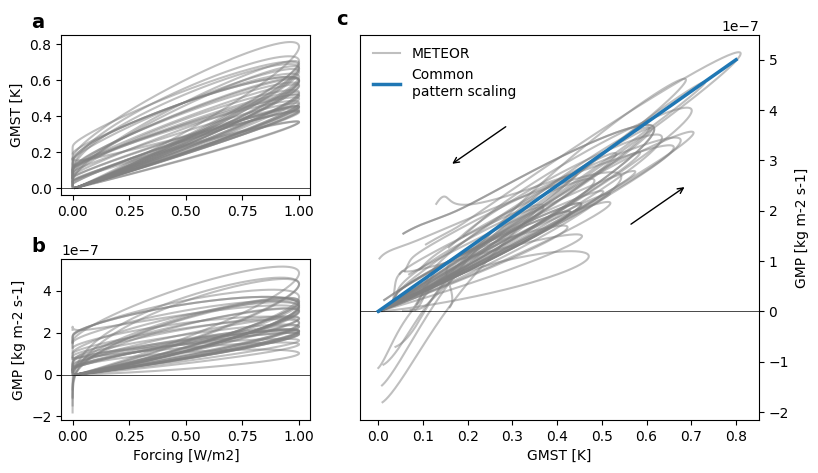

In [49]:
fig = plt.figure(figsize=(9,5))

nrows = 2
ncols = 5
X = [ (1,2), (3,5),
      (6,7),]

# ---------- subfig 1
sub = fig.add_subplot(nrows, ncols, X[0])
#sub.set_xlabel("Forcing [W/m2]")
sub.set_ylabel("GMST [K]")
for nm,mname in enumerate(models):
    sub.plot(f, global_mean(CMIP_pattern_dict[mname].predict_from_forcing_profile(f, 'tas', exp="co2x4")), color="gray", alpha=0.5)
sub.axhline(0, lw=0.5, color="black")
#sub.plot(f, f*0.6, lw=2, color="tab:blue", label="Common pattern scaling")
sub.annotate('a', xy=(-0.12, 1.08), xycoords='axes fraction', fontsize=14, ha='left', va='center', weight="bold")

# ---------- subfig 2
sub = fig.add_subplot(1, ncols, X[1])
sub.set_xlabel("GMST [K]")
sub.set_ylabel("GMP [kg m-2 s-1]")
sub.yaxis.set_label_position("right")
sub.yaxis.tick_right()
for nm,mname in enumerate(models):
    if nm == 0:
        sub.plot(global_mean(CMIP_pattern_dict[mname].predict_from_forcing_profile(f, 'tas', exp="co2x4")), 
            global_mean(CMIP_pattern_dict[mname].predict_from_forcing_profile(f, 'pr', exp="co2x4")),
            color="gray", alpha=0.5, label="METEOR")
    else:
        sub.plot(global_mean(CMIP_pattern_dict[mname].predict_from_forcing_profile(f, 'tas', exp="co2x4")), 
            global_mean(CMIP_pattern_dict[mname].predict_from_forcing_profile(f, 'pr', exp="co2x4")),
            color="gray", alpha=0.5)
sub.axhline(0, lw=0.5, color="black")
sub.plot([0,0.8], [0,5e-7], lw=2.5, color="tab:blue", label="Common\npattern scaling")
sub.legend(frameon=False, loc="upper left")
sub.annotate('c', xy=(-0.06, 1.04), xycoords='axes fraction', fontsize=14, ha='left', va='center', weight="bold")  

sub.annotate('', xytext=(0.56, 1.7e-7), xy=(0.69, 2.5e-7), arrowprops=dict(arrowstyle='->'))
sub.annotate('', xytext=(0.29, 3.7e-7), xy=(0.16, 2.9e-7), arrowprops=dict(arrowstyle='->'))

# ---------- subfig 3
sub = fig.add_subplot(nrows, ncols, X[2])
sub.set_xlabel("Forcing [W/m2]")
sub.set_ylabel("GMP [kg m-2 s-1]")
for nm,mname in enumerate(models):
    sub.plot(f, global_mean(CMIP_pattern_dict[mname].predict_from_forcing_profile(f, 'pr', exp="co2x4")), color="gray", alpha=0.5, label="METEOR")
sub.axhline(0, lw=0.5, color="black")
#sub.plot(f, f*3e-7, lw=2, color="tab:blue")
sub.annotate('b', xy=(-0.12, 1.08), xycoords='axes fraction', fontsize=14, ha='left', va='center', weight="bold")  
        
fig.subplots_adjust(wspace=0.5, hspace=0.4)
plt.savefig(os.path.join(figdir, "METEOR_conceptual_reversibility.pdf"), bbox_inches='tight')


In [56]:
%%capture

# also capture the spatial response of the last 20 years (2080--2100)

target_model_grid = 'ACCESS-CM2'

common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

patterns_aer_ssp_common_grid=np.zeros([len(models),len(scenarios),len(flds), len(common_lats), len(common_lons)])
patterns_aer_ssp_common_grid_gp=np.zeros([len(models),len(flds)])  #(tmp: for testing hysteresis plot)

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for nsc,sc in enumerate(scenarios):

                native_data = np.nanmean(np.sum(CMIP_pattern_dict[mname].predict_from_combined_experiment(
                        em_data_fwd[nsc], conc_data_fwd[nsc], [var],
                        return_patterns_per_mode=True
                )[var].values[:,-20:,:,:],0),0)
                native_lons = CMIP_pattern_dict[mname].predict_from_combined_experiment(em_data_fwd[nsc], conc_data_fwd[nsc], [var], return_patterns_per_mode=True)[var].lon
                native_lats = CMIP_pattern_dict[mname].predict_from_combined_experiment(em_data_fwd[nsc], conc_data_fwd[nsc], [var], return_patterns_per_mode=True)[var].lat
                native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
                # Interpolate
                patterns_aer_ssp_common_grid[nm,nsc,nv,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')


KeyboardInterrupt: 

In [127]:
# save aerosol dataset for later use
CMIP_pattern_dict_gm = np.zeros([len(models),len(flds),251])
for nm,mname in enumerate(models):
    CMIP_pattern_dict_gm[nm,0,:] = global_mean(CMIP_pattern_dict[mname].dacanom['tas'][CMIP_pattern_dict[mname].exp_list.index('sulxanom'), :251, :, :]) #- np.nanmean(global_mean(CMIP_pattern_dict[mname].dacanom['tas'][CMIP_pattern_dict[mname].exp_list.index('sulxanom'), 0:50, :, :]))
    CMIP_pattern_dict_gm[nm,1,:] = global_mean(CMIP_pattern_dict[mname].dacanom['pr'][CMIP_pattern_dict[mname].exp_list.index('sulxanom'), :251, :, :]) #- np.nanmean(global_mean(CMIP_pattern_dict[mname].dacanom['pr'][CMIP_pattern_dict[mname].exp_list.index('sulxanom'), 0:50, :, :]))

In [39]:
# delete here to make 'space' for follow-up calculations
#del(CMIP_pattern_dict)
###del(patterns_ghg)
###del(patterns_anomsulf)

In [ ]:
fig = plt.figure(figsize=(9,6))

sub = fig.add_subplot(2, 2, 1)
sub.set_title("abrupt-4xCO$_2$", size=10)
sub.set_xlabel("Years")
sub.set_ylabel("$\Delta$GMST [K]")
#sub.set_xlim(0,100)
#sub.set_ylim(0,8)
for nm,mname in enumerate(models):
    sub.plot(CMIP_ghg_pattern_dict_gm[nm,0,:], color="gray", alpha=0.3)
sub.plot(np.nanmean(CMIP_GHG_gm_response_co2x4[0,:,:],0), color="black", lw=2, label="CMIP6 models")
sub.plot(np.nanmean(CMIP_GHG_gm_response_recon_co2x4[0,:,:],0), color="tab:red", lw=2.5, label="Reconstruction GHG")
sub.axhline(0, color="black", lw=0.5, zorder=0)
sub.legend(frameon=False)
sub.annotate('a', xy=(-0.06, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

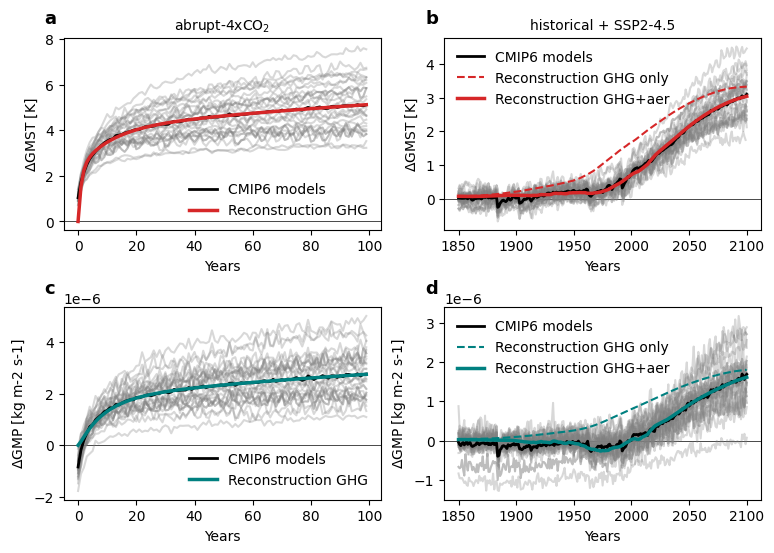

In [128]:
fig = plt.figure(figsize=(9,6))

sub = fig.add_subplot(2, 2, 1)
sub.set_title("abrupt-4xCO$_2$", size=10)
sub.set_xlabel("Years")
sub.set_ylabel("$\Delta$GMST [K]")
#sub.set_xlim(0,100)
#sub.set_ylim(0,8)
for nm,mname in enumerate(models):
    sub.plot(CMIP_ghg_pattern_dict_gm[nm,0,:], color="gray", alpha=0.3)
sub.plot(np.nanmean(CMIP_GHG_gm_response_co2x4[0,:,:],0), color="black", lw=2, label="CMIP6 models")
sub.plot(np.nanmean(CMIP_GHG_gm_response_recon_co2x4[0,:,:],0), color="tab:red", lw=2.5, label="Reconstruction GHG")
sub.axhline(0, color="black", lw=0.5, zorder=0)
sub.legend(frameon=False)
sub.annotate('a', xy=(-0.06, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(2, 2, 2)
sub.set_title("historical + SSP2-4.5", size=10)
sub.set_xlabel("Years")
sub.set_ylabel("$\Delta$GMST [K]")
#sub.set_xlim(0,100)
#sub.set_ylim(0,8)
for nm,mname in enumerate(models):
    sub.plot(np.arange(1850,2101), CMIP_pattern_dict_gm[nm,0,:], color="gray", alpha=0.3)
sub.plot(np.arange(1850,2101), np.nanmean(CMIP_aer_gm_response_sulxanom[0,:,:],0), color="black", lw=2, label="CMIP6 models")
sub.plot(np.arange(1850,2101), np.nanmean(CMIP_aer_gm_response_recon_ghgonly[0,:,:],0), color="tab:red", lw=1.5, label="Reconstruction GHG only", linestyle='--')
sub.plot(np.arange(1850,2101), np.nanmean(CMIP_aer_gm_response_recon_sulxanom[0,:,:],0), color="tab:red", lw=2.5, label="Reconstruction GHG+aer")
sub.axhline(0, color="black", lw=0.5, zorder=0)
sub.legend(frameon=False)
sub.annotate('b', xy=(-0.06, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(2, 2, 3)
sub.set_xlabel("Years")
sub.set_ylabel("$\Delta$GMP [kg m-2 s-1]")
#sub.set_xlim(0,100)
#sub.set_ylim(0,8)
for nm,mname in enumerate(models):
    sub.plot(CMIP_ghg_pattern_dict_gm[nm,1,:], color="gray", alpha=0.3)
sub.plot(np.nanmean(CMIP_GHG_gm_response_co2x4[1,:,:],0), color="black", lw=2, label="CMIP6 models")
sub.plot(np.nanmean(CMIP_GHG_gm_response_recon_co2x4[1,:,:],0), color="teal", lw=2.5, label="Reconstruction GHG")
sub.axhline(0, color="black", lw=0.5, zorder=0)
sub.legend(frameon=False)
sub.annotate('c', xy=(-0.06, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(2, 2, 4)
sub.set_xlabel("Years")
sub.set_ylabel("$\Delta$GMP [kg m-2 s-1]")
#sub.set_xlim(0,100)
#sub.set_ylim(0,8)
for nm,mname in enumerate(models):
    sub.plot(np.arange(1850,2101), CMIP_pattern_dict_gm[nm,1,:], color="gray", alpha=0.3)
sub.plot(np.arange(1850,2101), np.nanmean(CMIP_aer_gm_response_sulxanom[1,:,:],0), color="black", lw=2, label="CMIP6 models")
sub.plot(np.arange(1850,2101), np.nanmean(CMIP_aer_gm_response_recon_ghgonly[1,:,:],0), color="teal", lw=1.5, label="Reconstruction GHG only", linestyle='--')
sub.plot(np.arange(1850,2101), np.nanmean(CMIP_aer_gm_response_recon_sulxanom[1,:,:],0), color="teal", lw=2.5, label="Reconstruction GHG+aer")
sub.axhline(0, color="black", lw=0.5, zorder=0)
sub.legend(frameon=False)
sub.annotate('d', xy=(-0.06, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.2, hspace=0.4)
plt.savefig(os.path.join(figdir, "CMIP_GHG_aer_reconstruction_composite.pdf"), bbox_inches='tight')

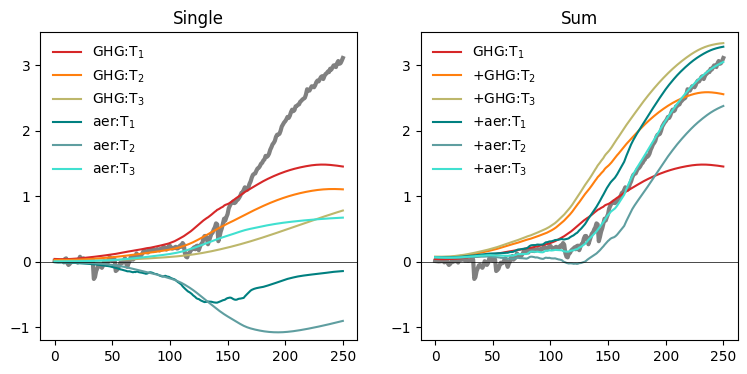

In [182]:
fig = plt.figure(figsize=(9,4))

sub = fig.add_subplot(1, 2, 1)
sub.set_title("Single")
sub.set_ylim(-1.2,3.5)
sub.plot(np.nanmean(CMIP_aer_gm_response_sulxanom[0,:,:],0), color="gray", lw=3)
sub.plot(np.nanmean(patterns_gm[0,:,0,100:],0), label="GHG:T$_1$", color="tab:red")
sub.plot(np.nanmean(patterns_gm[0,:,1,100:],0), label="GHG:T$_2$", color="tab:orange")
sub.plot(np.nanmean(patterns_gm[0,:,2,100:],0), label="GHG:T$_3$", color="darkkhaki")
sub.plot(np.nanmean(patterns_gm[0,:,3,100:],0), label="aer:T$_1$", color="teal")
sub.plot(np.nanmean(patterns_gm[0,:,4,100:],0), label="aer:T$_2$", color="cadetblue")
sub.plot(np.nanmean(patterns_gm[0,:,5,100:],0), label="aer:T$_3$", color="turquoise")
sub.axhline(0, color="black", lw=0.5)
sub.legend(frameon=False)

sub = fig.add_subplot(1, 2, 2)
sub.set_title("Sum")
sub.set_ylim(-1.2,3.5)
sub.plot(np.nanmean(CMIP_aer_gm_response_sulxanom[0,:,:],0), color="gray", lw=3)
sub.plot(np.nanmean(patterns_gm[0,:,0,100:],0), label="GHG:T$_1$", color="tab:red")
sub.plot(np.nanmean(np.sum(patterns_gm[0,:,0:2,100:],1),0), label="+GHG:T$_2$", color="tab:orange")
sub.plot(np.nanmean(np.sum(patterns_gm[0,:,0:3,100:],1),0), label="+GHG:T$_3$", color="darkkhaki")
sub.plot(np.nanmean(np.sum(patterns_gm[0,:,0:4,100:],1),0), label="+aer:T$_1$", color="teal")
sub.plot(np.nanmean(np.sum(patterns_gm[0,:,0:5,100:],1),0), label="+aer:T$_2$", color="cadetblue")
sub.plot(np.nanmean(np.sum(patterns_gm[0,:,0:6,100:],1),0), label="+aer:T$_3$", color="turquoise")
sub.axhline(0, color="black", lw=0.5)
sub.legend(frameon=False)



# Evaluation of timescale separation

In [16]:
%%capture

timescales_ghg=[1,2,3,4]
timescales_aer=[1,2,3,4]
tser_og_ghg = np.zeros([len(flds),len(models),len(timescales_ghg),100]) * np.nan
tser_fit_ghg = np.zeros([len(flds),len(models),len(timescales_ghg),100]) * np.nan
mae_ghg = np.zeros([len(flds),len(models),len(timescales_ghg)]) * np.nan
rmse_ghg = np.zeros([len(flds),len(models),len(timescales_ghg)]) * np.nan
tser_og_aer = np.zeros([len(flds),len(models),len(timescales_ghg),len(timescales_aer),251]) * np.nan
tser_fit_aer = np.zeros([len(flds),len(models),len(timescales_ghg),len(timescales_aer),251]) * np.nan
mae_aer = np.zeros([len(flds),len(models),len(timescales_ghg),len(timescales_aer)]) * np.nan
rmse_aer = np.zeros([len(flds),len(models),len(timescales_ghg),len(timescales_aer)]) * np.nan
CMIP_pattern_dict_tscales = {}

for nm,mname in enumerate(models):

    # create GHG modes and spatial pattern
    for ntsg,tsg in enumerate(timescales_ghg):
        for ntsa,tsa in enumerate(timescales_aer):

            CMIP_pattern_dict_tscales = MeteorPatternScaling(
                    mname,
                    {"tas": tsg, "pr": tsg},
                    lambda key: training_data_dict[mname][key],
                    from_file=False,
                    exp_list=["base", "co2x4", "sulxanom"],
                    anom_timescales={"tas": tsa, "pr": tsa}
                )

            # calculate goodness of the fit vs. orginal data
            for nv,var in enumerate(flds):
                # ghg
                tser_og_ghg[nv,nm,ntsg,:] = global_mean(CMIP_pattern_dict_tscales.dacanom[var][CMIP_pattern_dict_tscales.exp_list.index('co2x4'), :100, :, :])
                tser_fit_ghg[nv,nm,ntsg,:] = global_mean(recon(CMIP_pattern_dict_tscales.pattern_dict['co2x4'][var]['pattern_full']))
                mae_ghg[nv,nm,ntsg] = np.abs(tser_og_ghg[nv,nm,ntsg,:]-tser_fit_ghg[nv,nm,ntsg,:]).mean()
                rmse_ghg[nv,nm,ntsg] = np.sqrt(np.mean((tser_og_ghg[nv,nm,ntsg,:]-tser_fit_ghg[nv,nm,ntsg,:])**2))
                # ghg+aer
                tser_og_aer[nv,nm,ntsg,ntsa,:] = global_mean(CMIP_pattern_dict_tscales.dacanom[var][CMIP_pattern_dict_tscales.exp_list.index('sulxanom'), :251, :, :])
                tser_fit_aer[nv,nm,ntsg,ntsa,:] = global_mean(np.sum(CMIP_pattern_dict_tscales.predict_from_combined_experiment(em_data, conc_data, ["pr", "tas"], return_patterns_per_mode=True)[var][:,100:,:,:],0))
                mae_aer[nv,nm,ntsg,ntsa] = np.abs(tser_og_aer[nv,nm,ntsg,ntsa,:]-tser_fit_aer[nv,nm,ntsg,ntsa,:]).mean()
                rmse_aer[nv,nm,ntsg,ntsa] = np.sqrt(np.mean((tser_og_aer[nv,nm,ntsg,ntsa,:]-tser_fit_aer[nv,nm,ntsg,ntsa,:])**2))
                


In [18]:
%%capture

# prepare figure canvas
fig = plt.figure(figsize=(12,len(models)*2.5))
gs = GridSpec(len(models), 2, figure=fig)

for nm,mname in enumerate(models):

    sub = fig.add_subplot(gs[nm, 0])
    sub.set_xlabel("Years")
    sub.set_ylabel("$\Delta$GMST [K]")
    sub.plot(tser_og_aer[0,nm,0,0,:])
    sub.plot(tser_fit_aer[0,nm,0,0,:], label="ghg:1, aer:1")
    sub.plot(tser_fit_aer[0,nm,1,0,:], label="ghg:2, aer:1")
    sub.plot(tser_fit_aer[0,nm,2,0,:], label="ghg:3, aer:1")
    sub.plot(tser_fit_aer[0,nm,0,1,:], label="ghg:1, aer:2")
    sub.plot(tser_fit_aer[0,nm,1,1,:], label="ghg:2, aer:2")
    sub.plot(tser_fit_aer[0,nm,2,1,:], label="ghg:3, aer:2")
    sub.plot(tser_fit_aer[0,nm,0,2,:], label="ghg:1, aer:3")
    sub.plot(tser_fit_aer[0,nm,1,2,:], label="ghg:2, aer:3")
    sub.plot(tser_fit_aer[0,nm,2,2,:], label="ghg:3, aer:3")
    sub.legend(frameon=False, loc="upper left", ncol=2, prop={'size': 9})
    sub.annotate(mname, xy=(0.7, 0.04), xycoords='axes fraction', fontsize=10, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nm, 1])
    sub.set_xlabel("Years")
    sub.set_ylabel("$\Delta$GMP [kg m-2 s-1]")
    sub.plot(tser_og_aer[1,nm,0,0,:])
    sub.plot(tser_fit_aer[1,nm,0,0,:], label="ghg:1, aer:1")
    sub.plot(tser_fit_aer[1,nm,1,0,:], label="ghg:2, aer:1")
    sub.plot(tser_fit_aer[1,nm,2,0,:], label="ghg:3, aer:1")
    sub.plot(tser_fit_aer[1,nm,0,1,:], label="ghg:1, aer:2")
    sub.plot(tser_fit_aer[1,nm,1,1,:], label="ghg:2, aer:2")
    sub.plot(tser_fit_aer[1,nm,2,1,:], label="ghg:3, aer:2")
    sub.plot(tser_fit_aer[1,nm,0,2,:], label="ghg:1, aer:3")
    sub.plot(tser_fit_aer[1,nm,1,2,:], label="ghg:2, aer:3")
    sub.plot(tser_fit_aer[1,nm,2,2,:], label="ghg:3, aer:3")
    sub.legend(frameon=False, loc="upper left", ncol=2, prop={'size': 9})

plt.savefig(os.path.join(figdir, "CMIP_timescales_fit_individual.jpg"), bbox_inches='tight')

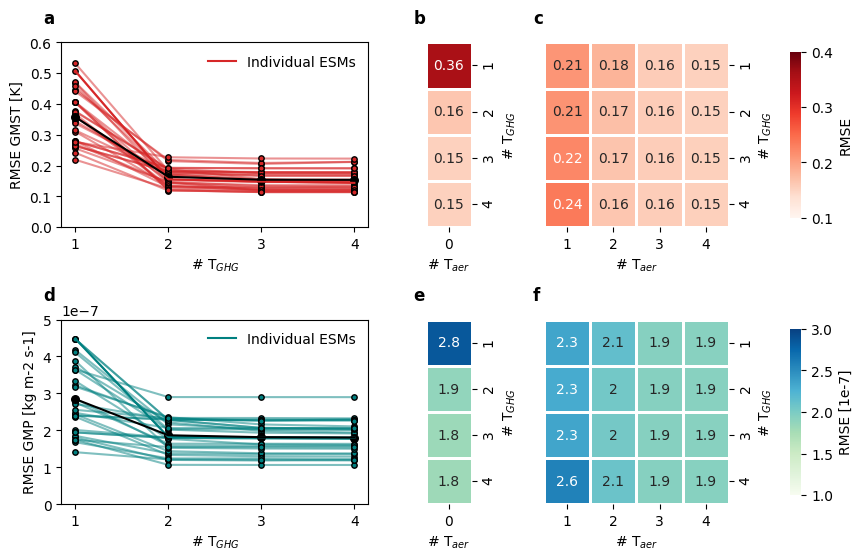

In [21]:
cbar_kws_tas = {"shrink": 0.9, "aspect": 15, "pad": 0.2, "label": "RMSE"}
cbar_kws_pr = {"shrink": 0.9, "aspect": 15, "pad": 0.2, "label": "RMSE [1e-7]"}

fig = plt.figure(figsize=(10,6))

nrows = 2
ncols = 7
X = [ (1,3), (4,4), (5,7),
      (8,10), (11,11), (12,14)]

## first row
sub = fig.add_subplot(2, ncols, X[0])
sub.set_ylabel('RMSE GMST [K]')
sub.set_xlabel('# T$_{GHG}$')
sub.set_ylim(0,0.6)
sub.set_xticks([0,1,2,3])
sub.set_xticklabels([1,2,3,4])
for m in np.arange(0,rmse_ghg.shape[1]):
    if m == 0: sub.plot(rmse_ghg[0,m,:], color='tab:red', label="Individual ESMs")
    sub.plot(rmse_ghg[0,m,:], color='tab:red',alpha=0.5,zorder=0)
    sub.scatter(np.arange(0,4), rmse_ghg[0,m,:], color='tab:red', s=15, edgecolor="black")
sub.plot(np.nanmean(rmse_ghg[0,:,:],0), color='black',lw=1.5)
sub.scatter(np.arange(0,4), np.nanmean(rmse_ghg[0,:,:],0), color='black', s=30, edgecolor="black")
sub.legend(frameon=False)
sub.annotate('a', xy=(-0.06, 1.13), xycoords='axes fraction', fontsize=12, ha='left', va='center', weight="bold")

sub = fig.add_subplot(2, ncols, X[1])
sns.heatmap(pd.DataFrame(np.nanmean(rmse_ghg[0,:,:],0)), ax=sub, annot=True, cmap='Reds', yticklabels=[1,2,3,4], xticklabels=[0], 
            vmin = 0.1, vmax = 0.4, linewidth=1, square=True, cbar=False)
sub.set_ylabel('# T$_{GHG}$')
sub.set_xlabel('# T$_{aer}$')
sub.yaxis.set_label_position("right")
sub.yaxis.tick_right()
sub.annotate('b', xy=(-0.26, 1.13), xycoords='axes fraction', fontsize=12, ha='left', va='center', weight="bold")

sub = fig.add_subplot(2, ncols, X[2])
sns.heatmap(np.nanmean(rmse_aer[0,:,:,:],0), annot=True, cmap='Reds', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4],
            vmin = 0.1, vmax = 0.4, linewidth=1, square=True, cbar=True, cbar_kws=cbar_kws_tas)
sub.set_ylabel('# T$_{GHG}$')
sub.set_xlabel('# T$_{aer}$')
sub.yaxis.set_label_position("right")
sub.yaxis.tick_right()
sub.annotate('c', xy=(-0.06, 1.13), xycoords='axes fraction', fontsize=12, ha='left', va='center', weight="bold")

## second row
sub = fig.add_subplot(2, ncols, X[3])
sub.set_ylabel('RMSE GMP [kg m-2 s-1]')
sub.set_xlabel('# T$_{GHG}$')
sub.set_ylim(0,5e-7)
sub.set_xticks([0,1,2,3])
sub.set_xticklabels([1,2,3,4])
for m in np.arange(0,rmse_ghg.shape[1]):
    if m == 0: sub.plot(rmse_ghg[1,m,:], color='teal', label="Individual ESMs")
    sub.plot(rmse_ghg[1,m,:], color='teal',alpha=0.5,zorder=0)
    sub.scatter(np.arange(0,4), rmse_ghg[1,m,:], color='teal', s=15, edgecolor="black")
sub.plot(np.nanmean(rmse_ghg[1,:,:],0), color='black',lw=1.5)
sub.scatter(np.arange(0,4), np.nanmean(rmse_ghg[1,:,:],0), color='black', s=30, edgecolor="black")
sub.legend(frameon=False)
sub.annotate('d', xy=(-0.06, 1.13), xycoords='axes fraction', fontsize=12, ha='left', va='center', weight="bold")

sub = fig.add_subplot(2, ncols, X[4])
sns.heatmap(pd.DataFrame(np.nanmean(rmse_ghg[1,:,:],0))*1e7, ax=sub, annot=True, cmap='GnBu', yticklabels=[1,2,3,4], xticklabels=[0], 
            vmin = 1, vmax = 3, linewidth=1, square=True, cbar=False)
sub.set_ylabel('# T$_{GHG}$')
sub.set_xlabel('# T$_{aer}$')
sub.yaxis.set_label_position("right")
sub.yaxis.tick_right()
sub.annotate('e', xy=(-0.26, 1.13), xycoords='axes fraction', fontsize=12, ha='left', va='center', weight="bold")

sub = fig.add_subplot(2, ncols, X[5])

sns.heatmap(np.nanmean(rmse_aer[1,:,:,:],0)*1e7, annot=True, cmap='GnBu', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4],
            vmin = 1, vmax = 3, linewidth=1, square=True, cbar=True, cbar_kws=cbar_kws_pr)
sub.set_ylabel('# T$_{GHG}$')
sub.set_xlabel('# T$_{aer}$')
sub.yaxis.set_label_position("right")
sub.yaxis.tick_right()
sub.annotate('f', xy=(-0.06, 1.13), xycoords='axes fraction', fontsize=12, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.6, hspace=0.5)

plt.savefig(os.path.join(figdir, "fit_timescale_evaluation.pdf"), bbox_inches='tight')

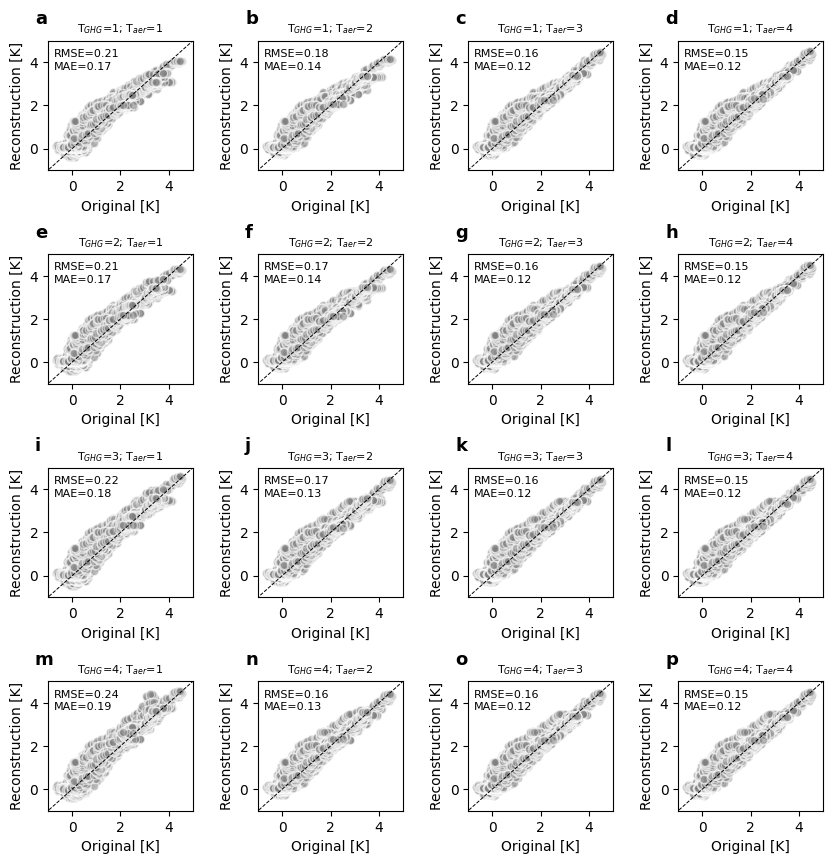

In [344]:
labels = (["a","b","c","d"],
          ["e","f","g","h"],
          ["i","j","k","l"],
          ["m","n","o","p"],)

fig = plt.figure(figsize=(10,10))
gs = GridSpec(len(timescales_ghg), len(timescales_aer), figure=fig)

nv = 0
for ntscg,tscg in enumerate(timescales_ghg):
    for ntsca,tsca in enumerate(timescales_aer):
        sub = fig.add_subplot(gs[ntscg, ntsca])
        sub.set_title("T$_{GHG}$="+str(tscg)+"; T$_{aer}$="+str(tsca), size=8)
        sub.set_xlabel("Original [K]")
        sub.set_ylabel("Reconstruction [K]")
        sub.set_ylim(-1,5)
        sub.set_xlim(-1,5)
        #sub.set_xticks([0,1,2,3,4])
        #sub.set_xticklabels([1,2,3,4,5])
        for m in np.arange(0,tser_og_aer.shape[1]):
            sub.scatter(tser_og_aer[nv,m,ntscg,ntsca,:], tser_fit_aer[nv,m,ntscg,ntsca,:], color="gray", alpha=0.5, edgecolor="white")
        sub.plot([-100,100],[-100,100], color="black", lw=0.7, linestyle="--")
        sub.annotate(labels[ntscg][ntsca], xy=(-0.09, 1.17), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
        sub.annotate("RMSE="+"{:.2f}".format(np.nanmean(rmse_aer[nv,:,ntscg, ntsca])), xy=(0.04, 0.9), xycoords='axes fraction', fontsize=8, ha='left', va='center')
        sub.annotate("MAE="+"{:.2f}".format(np.nanmean(mae_aer[nv,:,ntscg, ntsca])), xy=(0.04, 0.8), xycoords='axes fraction', fontsize=8, ha='left', va='center')
        
fig.subplots_adjust(wspace=0.45, hspace=0.65)
plt.savefig(os.path.join(figdir, "fit_timescale_evaluation_scatter_tas.pdf"), bbox_inches='tight')

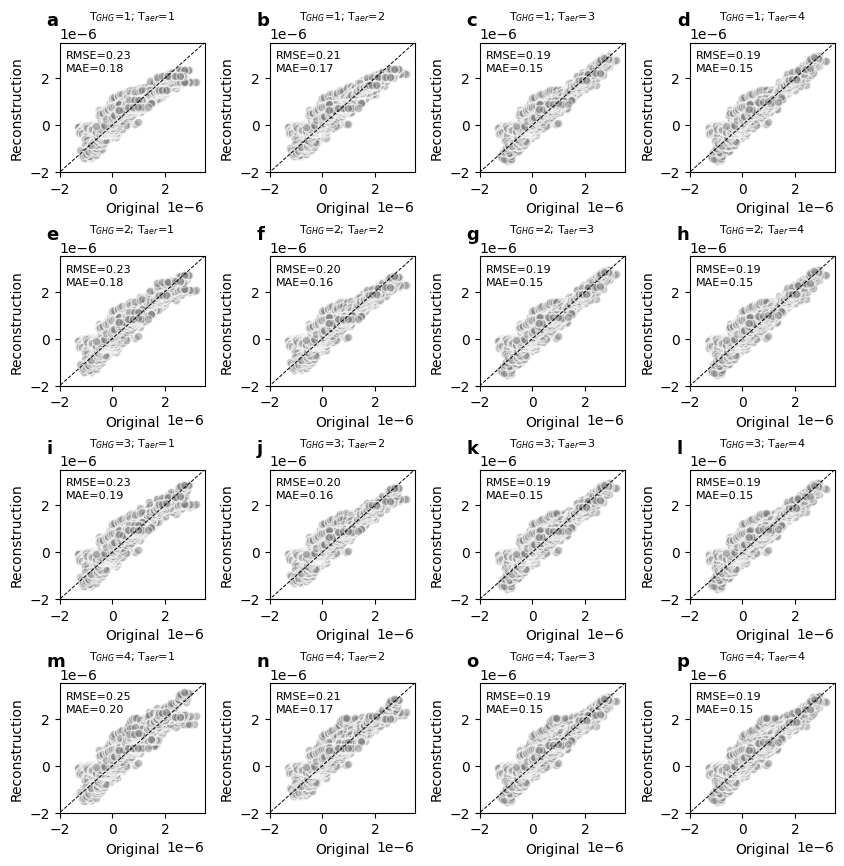

In [345]:
labels = (["a","b","c","d"],
          ["e","f","g","h"],
          ["i","j","k","l"],
          ["m","n","o","p"],)

fig = plt.figure(figsize=(10,10))
gs = GridSpec(len(timescales_ghg), len(timescales_aer), figure=fig)

nv = 1
for ntscg,tscg in enumerate(timescales_ghg):
    for ntsca,tsca in enumerate(timescales_aer):
        sub = fig.add_subplot(gs[ntscg, ntsca])
        sub.set_title("T$_{GHG}$="+str(tscg)+"; T$_{aer}$="+str(tsca), size=8)
        sub.set_xlabel("Original")
        sub.set_ylabel("Reconstruction")
        sub.set_ylim(-2e-6,3.5e-6)
        sub.set_xlim(-2e-6,3.5e-6)
        #sub.set_xticks([0,1,2,3,4])
        #sub.set_xticklabels([1,2,3,4,5])
        for m in np.arange(0,tser_og_aer.shape[1]):
            sub.scatter(tser_og_aer[nv,m,ntscg,ntsca,:], tser_fit_aer[nv,m,ntscg,ntsca,:], color="gray", alpha=0.5, edgecolor="white")
        sub.plot([-100,100],[-100,100], color="black", lw=0.7, linestyle="--")
        sub.annotate(labels[ntscg][ntsca], xy=(-0.09, 1.17), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
        sub.annotate("RMSE="+"{:.2f}".format(np.nanmean(rmse_aer[nv,:,ntscg, ntsca])*1e6), xy=(0.04, 0.9), xycoords='axes fraction', fontsize=8, ha='left', va='center')
        sub.annotate("MAE="+"{:.2f}".format(np.nanmean(mae_aer[nv,:,ntscg, ntsca])*1e6), xy=(0.04, 0.8), xycoords='axes fraction', fontsize=8, ha='left', va='center')
        
fig.subplots_adjust(wspace=0.45, hspace=0.65)
plt.savefig(os.path.join(figdir, "fit_timescale_evaluation_scatter_pr.pdf"), bbox_inches='tight')

# Application to new scenarios

### SSP534-over

In [21]:
%%capture
# Only for SSP534-over
# make sure that all data for the models from the SSP534-over list are available in training_data_dict (i.e. in cache)

target_model_grid = 'ACCESS-CM2'
common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)
patterns_ssp534_common_grid=np.zeros([len(models_ssp534),1,len(flds), len(common_lats), len(common_lons)])

#patterns_ghg_ssp534={}
patterns_ssp534={}

for nm,mname in enumerate(models_ssp534):
    #patterns_ghg_ssp534[mname]={}
    patterns_ssp534[mname]={}

    # create GHG modes and spatial pattern
    #CMIP_ghg_pattern={}
    #CMIP_ghg_pattern = MeteorPatternScaling(
    #        mname,
    #        {"tas": 3, "pr": 3},
    #        lambda key: training_data_dict_ssp534[mname][key],
    #        from_file=False,
    #        exp_list=["base", "co2x4"],
    #        anom_timescales={"tas": 3, "pr": 3}
    #    )

    # create GHG modes and spatial pattern
    CMIP_pattern_ssp534={}
    CMIP_pattern_ssp534 = MeteorPatternScaling(
            mname,
            {"tas": 3, "pr": 3},
            lambda key: training_data_dict_ssp534[mname][key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
            anom_timescales={"tas": 3, "pr": 3}
        )

    for nsc,sc in enumerate(['ssp534-over']):
        #patterns_ghg_ssp534[mname][sc] = CMIP_ghg_pattern.predict_from_combined_experiment(
        #        em_data_ssp534[nsc], conc_data_ssp534[nsc], ["pr", "tas"],
        #        return_patterns_per_mode=True
        #)
        patterns_ssp534[mname][sc] = CMIP_pattern_ssp534.predict_from_combined_experiment(
                em_data_ssp534[nsc], conc_data_ssp534[nsc], ["pr", "tas"],
                return_patterns_per_mode=True
        )

        # Interpolation for spatial pattern evaluation plots
        for nv,var in enumerate(flds):
            native_data = np.nanmean(np.sum(CMIP_pattern_ssp534.predict_from_combined_experiment(
                    em_data_ssp534[nsc], conc_data_ssp534[nsc], [var],
                    return_patterns_per_mode=True
            )[var].values[:,-20:,:,:],0),0)
            native_lons = CMIP_pattern_ssp534.predict_from_combined_experiment(em_data_ssp534[nsc], conc_data_ssp534[nsc], [var], return_patterns_per_mode=True)[var].lon
            native_lats = CMIP_pattern_ssp534.predict_from_combined_experiment(em_data_ssp534[nsc], conc_data_ssp534[nsc], [var], return_patterns_per_mode=True)[var].lat
            native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            # Interpolate
            patterns_ssp534_common_grid[nm,nsc,nv,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                        np.array(native_data).flatten(), 
                                        (common_lon_grid, common_lat_grid), method='cubic')

In [85]:
### global mean timeseries (standard SSPs)
td_ssp = np.zeros([len(flds),len(models),len(scenarios),251]) * np.nan

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
            for nsc,sc in enumerate(scenarios):
                dur = global_mean(training_data_dict[mname][sc]['tas']).values[0,:].shape[0]
                if dur > 251: dur = 251
                else: dur = dur
                #td_ssp[nv,nsc,nm,0:dur] = global_mean(training_data_dict[mname][sc][var]).values[0,0:dur]-np.nanmean(global_mean(training_data_dict[mname]["base"][var]).values[-500:])     # subtracting piC
                td_ssp[nv,nm,nsc,0:dur] = global_mean(training_data_dict[mname][sc][var]).values[0,0:dur] - np.nanmean(global_mean(training_data_dict[mname][sc][var]).values[0,0:50])     # subtracting first 50 year-average
#patterns_gm_ssp_gm = patterns_gm_ssp[:,:,:,:,100:]
#patterns_aer_ssp_gm = patterns_aer_ssp[:,:,:,:,100:]

### global mean timeseries (SSP534-over)
td_ssp534 = np.zeros([len(flds),len(models_ssp534),251]) * np.nan
#patterns_ghg_ssp534_gm = np.zeros([len(flds),len(models_ssp534),251]) * np.nan
patterns_ssp534_gm = np.zeros([len(flds),len(models_ssp534),6,251]) * np.nan
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models_ssp534):
        dur = global_mean(training_data_dict_ssp534[mname]['ssp534-over']['tas']).values[0,:].shape[0]
        if dur > 251: dur = 251
        else: dur = dur
        td_ssp534[nv,nm,0:dur] = global_mean(training_data_dict_ssp534[mname]['ssp534-over'][var]).values[0,0:dur] - np.nanmean(global_mean(training_data_dict_ssp534[mname]["base"][var]).values[0,0:50])
        for mode in np.arange(0,6):
            patterns_ssp534_gm[nv,nm,mode,:] = global_mean(patterns_ssp534[mname]['ssp534-over'][var][mode,100:,:,:])
            #patterns_aer_ssp534_gm[nv,nm,:] = global_mean(patterns_ssp534[mname]['ssp534-over'][var]).values[100:]


### Plotting

single model total response

In [87]:
%%capture

var_idx = 0  # tas
titles = ["SSP-1.26","SSP-2.45","SSP-3.70","SSP-5.85"]
midx534 = [i for i, element in enumerate(models) if element in models_ssp534]  # get indices of ssp534 models in all model array

fig = plt.figure(figsize=(15,len(models)*2.5))
gs = GridSpec(len(models), 5, figure=fig)

c534 = -1
for nm,mname in enumerate(models):
    # row-fig 1--4
    for sci in np.arange(0,4):
        sub = fig.add_subplot(gs[nm, sci])
        if nm == 0: sub.set_title(titles[sci])
        if sci == 0: sub.set_ylabel("$\Delta$GMST [K]")
        sub.plot(np.arange(1850,2101), td_ssp[var_idx,nm,sci,:], color="lightgray", label="Original")
        sub.plot(np.arange(1850,2101), np.nansum(patterns_gm_ssp[var_idx,nm,0:3,sci,100:],0), color="tab:orange", label="GHG only", lw=1.5, linestyle=':')
        sub.plot(np.arange(1850,2101), np.nansum(patterns_gm_ssp[var_idx,nm,:,sci,100:],0), color="tab:purple", label="GHG+aer", lw=1.5)
        if sci == 0: sub.annotate(mname, xy=(0.02, 0.92), xycoords='axes fraction', fontsize=10, ha='left', va='center', weight="bold")
        if sci == 0 and nm == 0: sub.legend(frameon=False, loc="upper left",bbox_to_anchor=[0,0.9], prop={'size': 9})
    # row-fig 5
    sub = fig.add_subplot(gs[nm, 4])
    if nm in midx534:
        c534 = c534+1
        if c534 == 0: sub.set_title('SSP-5.34-over')
        sub.plot(np.arange(1850,2101), td_ssp534[var_idx,c534,:], color="lightgray", label="Original")
        sub.plot(np.arange(1850,2101), np.nansum(patterns_ssp534_gm[var_idx,c534,0:3,:],0), color="tab:orange", label="GHG only", lw=1.5, linestyle=':')
        sub.plot(np.arange(1850,2101), np.nansum(patterns_ssp534_gm[var_idx,c534,:,:],0), color="tab:purple", label="GHG+aer", lw=1.5)
    else:
        sub.axis('off')

fig.subplots_adjust(wspace=0.2, hspace=0.2)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_tas_single.pdf"), bbox_inches='tight')


In [88]:
%%capture

var_idx = 1  # pr
titles = ["SSP-1.26","SSP-2.45","SSP-3.70","SSP-5.85"]
midx534 = [i for i, element in enumerate(models) if element in models_ssp534]  # get indices of ssp534 models in all model array

fig = plt.figure(figsize=(15,len(models)*2.5))
gs = GridSpec(len(models), 5, figure=fig)

c534 = -1
for nm,mname in enumerate(models):
    # row-fig 1--4
    for sci in np.arange(0,4):
        sub = fig.add_subplot(gs[nm, sci])
        if nm == 0: sub.set_title(titles[sci])
        if sci == 0: sub.set_ylabel("$\Delta$GMP [kg m-2 s-1]")
        sub.plot(np.arange(1850,2101), td_ssp[var_idx,nm,sci,:], color="lightgray", label="Original")
        sub.plot(np.arange(1850,2101), np.nansum(patterns_gm_ssp[var_idx,nm,0:3,sci,100:],0), color="tab:orange", label="GHG only", lw=1.5, linestyle=':')
        sub.plot(np.arange(1850,2101), np.nansum(patterns_gm_ssp[var_idx,nm,:,sci,100:],0), color="tab:purple", label="GHG+aer", lw=1.5)
        if sci == 0: sub.annotate(mname, xy=(0.02, 0.92), xycoords='axes fraction', fontsize=10, ha='left', va='center', weight="bold")
        if sci == 0 and nm == 0: sub.legend(frameon=False, loc="upper left",bbox_to_anchor=[0,0.9], prop={'size': 9})
    # row-fig 5
    sub = fig.add_subplot(gs[nm, 4])
    if nm in midx534:
        c534 = c534+1
        if c534 == 0: sub.set_title('SSP-5.34-over')
        sub.plot(np.arange(1850,2101), td_ssp534[var_idx,c534,:], color="lightgray", label="Original")
        sub.plot(np.arange(1850,2101), np.nansum(patterns_ssp534_gm[var_idx,c534,0:3,:],0), color="tab:orange", label="GHG only", lw=1.5, linestyle=':')
        sub.plot(np.arange(1850,2101), np.nansum(patterns_ssp534_gm[var_idx,c534,:,:],0), color="tab:purple", label="GHG+aer", lw=1.5)
    else:
        sub.axis('off')

fig.subplots_adjust(wspace=0.2, hspace=0.2)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_pr_single.pdf"), bbox_inches='tight')


Multi-model average total response 

In [111]:
patterns_gm_ssp.shape

(2, 30, 6, 4, 351)

In [136]:
patterns_ssp534_gm[var_idx,:,:,:].shape

(10, 6, 251)

In [143]:
np.nanmin(np.nansum(patterns_gm_ssp[var_idx,:,:,sci,-10:],1),0).shape

(10,)

In [178]:
patterns_ssp534_gm.shape

(2, 10, 6, 251)

In [204]:
np.nanmin(np.nanmean(td_ssp[var_idx,:,0,-10:],1),0)

1.2385075294619696

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_11383/121971411.py:63: RuntimeWarning: Mean of empty slice
  sub.scatter(4,np.nanmean(np.nanmean(td_ssp[var_idx,:,1,-10:],1),0), color="black", edgecolor="black")
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_11383/121971411.py:64: RuntimeWarning: Mean of empty slice
  sub.plot([4,4],[np.nanmin(np.nanmean(td_ssp[var_idx,:,1,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,:,1,-10:],1),0)], color="gray", lw=3, zorder=0)
/var/folders/mt/vkb75n9d7kx45p7qhp1

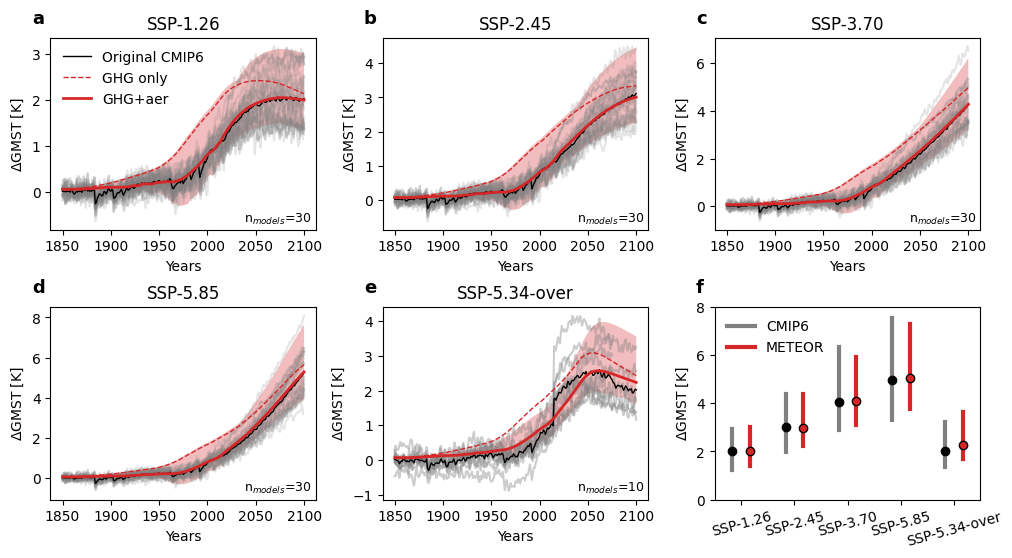

In [212]:
var_idx = 0

fig = plt.figure(figsize=(12,6))

gs = GridSpec(2, 3, figure=fig)

gsx = [0,0,0,1]
gsy = [0,1,2,0]
sublabel = ['a','b','c','d']
titles = ["SSP-1.26","SSP-2.45","SSP-3.70","SSP-5.85"]

# subfigures 1--4
for sci in np.arange(0,4):
    sub = fig.add_subplot(gs[gsx[sci], gsy[sci]])
    sub.set_title(titles[sci])
    sub.set_xlabel("Years")
    sub.set_ylabel("$\Delta$GMST [K]")
    #sub.set_ylim(-1,3.5)
    for nm,mname in enumerate(models):
        sub.plot(np.arange(1850,2101), td_ssp[var_idx,nm,sci,:], color="gray", alpha=0.2)
    if sci == 0:
        sub.plot(np.arange(1850,2101), np.nanmean(td_ssp[var_idx,:,sci,:],0), color="black", label="Original CMIP6", lw=1)
        sub.plot(np.arange(1850,2101), np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,0:3,sci,100:],1),0), color="tab:red", label="GHG only", lw=1,  linestyle='--')
        sub.plot(np.arange(1850,2101), np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,sci,100:],1),0), color="tab:red", label="GHG+aer", lw=2)
    else:
        sub.plot(np.arange(1850,2101), np.nanmean(td_ssp[var_idx,:,sci,:],0), color="black", lw=1)
        sub.plot(np.arange(1850,2101), np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,0:3,sci,100:],1),0), color="tab:red", lw=1, linestyle='--')
        sub.plot(np.arange(1850,2101), np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,sci,100:],1),0), color="tab:red", lw=2)
    sub.fill_between(np.arange(1850,2101), np.nanmin(np.nansum(patterns_gm_ssp[var_idx,:,:,sci,100:],1),0), np.nanmax(np.nansum(patterns_gm_ssp[var_idx,:,:,sci,100:],1),0), color="tab:red", alpha=0.3, edgecolor="none")
    sub.legend(frameon=False)
    sub.annotate(sublabel[sci], xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate('n$_{models}$='+str(len(models)), xy=(0.73, 0.06), xycoords='axes fraction', fontsize=9, ha='left', va='center')

# subfigure 5
sub = fig.add_subplot(gs[1, 1])
sub.set_title("SSP-5.34-over")
sub.set_xlabel("Years")
sub.set_ylabel("$\Delta$GMST [K]")
for nm,mname in enumerate(models_ssp534):
    sub.plot(np.arange(1850,2101), td_ssp534[var_idx,nm,:], color="gray", alpha=0.4)
    #sub.plot(np.arange(1850,2101), global_mean(training_data_dict_ssp534[mname]['ssp534-over']['tas']).values[0,:251]-np.nanmean(global_mean(training_data_dict_ssp534[mname]["base"]['tas']).values[-100:]), color="gray", alpha=0.2)
sub.plot(np.arange(1850,2101), np.nanmean(td_ssp534[var_idx,:,:],0), color="black", lw=1)
sub.plot(np.arange(1850,2101), np.nanmean(np.nansum(patterns_ssp534_gm[var_idx,:,0:3,:],1),0), color="tab:red", label="GHG only", lw=1, linestyle='--')
sub.plot(np.arange(1850,2101), np.nanmean(np.nansum(patterns_ssp534_gm[var_idx,:,:,:],1),0), color="tab:red", label="GHG+aer", lw=2)
sub.fill_between(np.arange(1850,2101), np.nanmin(np.nansum(patterns_ssp534_gm[var_idx,:,:,:],1),0), np.nanmax(np.nansum(patterns_ssp534_gm[var_idx,:,:,:],1),0), color="tab:red", alpha=0.3, edgecolor="none")
sub.annotate('e', xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('n$_{models}$='+str(len(models_ssp534)), xy=(0.73, 0.06), xycoords='axes fraction', fontsize=9, ha='left', va='center')

# subfigure 6
sub = fig.add_subplot(gs[1, 2])
sub.set_xlim(0,15)
sub.set_ylim(0,8)
sub.set_xticks([1.5,4.5,7.5,10.5,13.5])
sub.set_xticklabels(['SSP-1.26','SSP-2.45','SSP-3.70','SSP-5.85','SSP-5.34-over'], rotation=15)
sub.set_ylabel("$\Delta$GMST [K]")

sub.scatter(1,np.nanmean(np.nanmean(td_ssp[var_idx,:,0,-10:],1),0), color="black", edgecolor="black")
sub.plot([1,1],[np.nanmin(np.nanmean(td_ssp[var_idx,:,0,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,:,0,-10:],1),0)], color="gray", lw=3, zorder=0, label="CMIP6")
sub.scatter(2,np.nanmean(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,0,-10:],1),1),0), color="tab:red", edgecolor="black")
sub.plot([2,2],[np.nanmin(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,0,-10:],1),1),0),np.nanmax(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,0,-10:],1),1),0)], color="tab:red", lw=3, zorder=0, label="METEOR")
sub.legend(frameon=False, loc="upper left")

sub.scatter(4,np.nanmean(np.nanmean(td_ssp[var_idx,:,1,-10:],1),0), color="black", edgecolor="black")
sub.plot([4,4],[np.nanmin(np.nanmean(td_ssp[var_idx,:,1,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,:,1,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(5,np.nanmean(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,1,-10:],1),1),0), color="tab:red", edgecolor="black")
sub.plot([5,5],[np.nanmin(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,1,-10:],1),1),0),np.nanmax(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,1,-10:],1),1),0)], color="tab:red", lw=3, zorder=0)

sub.scatter(7,np.nanmean(np.nanmean(td_ssp[var_idx,:,2,-10:],1),0), color="black", edgecolor="black")
sub.plot([7,7],[np.nanmin(np.nanmean(td_ssp[var_idx,:,2,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,:,2,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(8,np.nanmean(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,2,-10:],1),1),0), color="tab:red", edgecolor="black")
sub.plot([8,8],[np.nanmin(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,2,-10:],1),1),0),np.nanmax(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,2,-10:],1),1),0)], color="tab:red", lw=3, zorder=0)

sub.scatter(10,np.nanmean(np.nanmean(td_ssp[var_idx,:,3,-10:],1),0), color="black", edgecolor="black")
sub.plot([10,10],[np.nanmin(np.nanmean(td_ssp[var_idx,:,3,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,:,3,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(11,np.nanmean(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,3,-10:],1),1),0), color="tab:red", edgecolor="black")
sub.plot([11,11],[np.nanmin(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,3,-10:],1),1),0),np.nanmax(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,3,-10:],1),1),0)], color="tab:red", lw=3, zorder=0)

sub.scatter(13,np.nanmean(np.nanmean(td_ssp534[var_idx,:,-10:],1),0), color="black", edgecolor="black")
sub.plot([13,13],[np.nanmin(np.nanmean(td_ssp534[var_idx,:,-10:],1),0),np.nanmax(np.nanmean(td_ssp534[var_idx,:,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(14,np.nanmean(np.nanmean(np.nansum(patterns_ssp534_gm[var_idx,:,:],1),0)[-10:]), color="tab:red", edgecolor="black")
sub.plot([14,14],[np.nanmin(np.nanmean(np.nansum(patterns_ssp534_gm[var_idx,:,:,-10:],1),1),0),np.nanmax(np.nanmean(np.nansum(patterns_ssp534_gm[var_idx,:,:,-10:],1),1),0)], color="tab:red", lw=3, zorder=0)
sub.annotate('f', xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.25, hspace=0.4)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_tas.pdf"), bbox_inches='tight')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_11383/738491423.py:63: RuntimeWarning: Mean of empty slice
  sub.scatter(4,np.nanmean(np.nanmean(td_ssp[var_idx,:,1,-10:],1),0), color="black", edgecolor="black")
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_11383/738491423.py:64: RuntimeWarning: Mean of empty slice
  sub.plot([4,4],[np.nanmin(np.nanmean(td_ssp[var_idx,:,1,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,:,1,-10:],1),0)], color="gray", lw=3, zorder=0)
/var/folders/mt/vkb75n9d7kx45p7qhp1

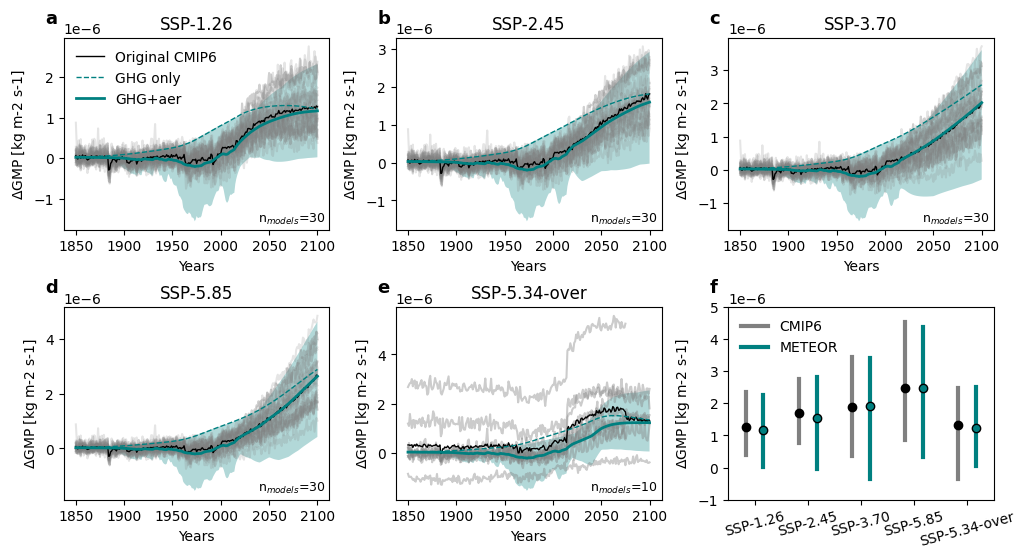

In [213]:
var_idx = 1

fig = plt.figure(figsize=(12,6))

gs = GridSpec(2, 3, figure=fig)

gsx = [0,0,0,1]
gsy = [0,1,2,0]
sublabel = ['a','b','c','d']
titles = ["SSP-1.26","SSP-2.45","SSP-3.70","SSP-5.85"]

# subfigures 1--4
for sci in np.arange(0,4):
    sub = fig.add_subplot(gs[gsx[sci], gsy[sci]])
    sub.set_title(titles[sci])
    sub.set_xlabel("Years")
    sub.set_ylabel("$\Delta$GMP [kg m-2 s-1]")
    #sub.set_ylim(-1,3.5)
    for nm,mname in enumerate(models):
        sub.plot(np.arange(1850,2101), td_ssp[var_idx,nm,sci,:], color="gray", alpha=0.2)
    if sci == 0:
        sub.plot(np.arange(1850,2101), np.nanmean(td_ssp[var_idx,:,sci,:],0), color="black", label="Original CMIP6", lw=1)
        sub.plot(np.arange(1850,2101), np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,0:3,sci,100:],1),0), color="teal", label="GHG only", lw=1, linestyle='--')
        sub.plot(np.arange(1850,2101), np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,sci,100:],1),0), color="teal", label="GHG+aer", lw=2)
    else:
        sub.plot(np.arange(1850,2101), np.nanmean(td_ssp[var_idx,:,sci,:],0), color="black", lw=1)
        sub.plot(np.arange(1850,2101), np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,0:3,sci,100:],1),0), color="teal", lw=1, linestyle='--')
        sub.plot(np.arange(1850,2101), np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,sci,100:],1),0), color="teal", lw=2)
    sub.fill_between(np.arange(1850,2101), np.nanmin(np.nansum(patterns_gm_ssp[var_idx,:,:,sci,100:],1),0), np.nanmax(np.nansum(patterns_gm_ssp[var_idx,:,:,sci,100:],1),0), color="teal", alpha=0.3, edgecolor="none")
    sub.legend(frameon=False)
    sub.annotate(sublabel[sci], xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate('n$_{models}$='+str(len(models)), xy=(0.73, 0.06), xycoords='axes fraction', fontsize=9, ha='left', va='center')

# subfigure 5
sub = fig.add_subplot(gs[1, 1])
sub.set_title("SSP-5.34-over")
sub.set_xlabel("Years")
sub.set_ylabel("$\Delta$GMP [kg m-2 s-1]")
for nm,mname in enumerate(models_ssp534):
    sub.plot(np.arange(1850,2101), td_ssp534[var_idx,nm,:], color="gray", alpha=0.4)
    #sub.plot(np.arange(1850,2101), global_mean(training_data_dict_ssp534[mname]['ssp534-over']['tas']).values[0,:251]-np.nanmean(global_mean(training_data_dict_ssp534[mname]["base"]['tas']).values[-100:]), color="gray", alpha=0.2)
sub.plot(np.arange(1850,2101), np.nanmean(td_ssp534[var_idx,:,:],0), color="black", lw=1)
sub.plot(np.arange(1850,2101), np.nanmean(np.nansum(patterns_ssp534_gm[var_idx,:,0:3,:],1),0), color="teal", label="GHG only", lw=1, linestyle='--')
sub.plot(np.arange(1850,2101), np.nanmean(np.nansum(patterns_ssp534_gm[var_idx,:,:,:],1),0), color="teal", label="GHG+aer", lw=2)
sub.fill_between(np.arange(1850,2101), np.nanmin(np.nansum(patterns_ssp534_gm[var_idx,:,:,:],1),0), np.nanmax(np.nansum(patterns_ssp534_gm[var_idx,:,:,:],1),0), color="teal", alpha=0.3, edgecolor="none")
sub.annotate('e', xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('n$_{models}$='+str(len(models_ssp534)), xy=(0.73, 0.06), xycoords='axes fraction', fontsize=9, ha='left', va='center')

# subfigure 6
sub = fig.add_subplot(gs[1, 2])
sub.set_xlim(0,15)
sub.set_ylim(-1e-6,5e-6)
sub.set_xticks([1.5,4.5,7.5,10.5,13.5])
sub.set_xticklabels(['SSP-1.26','SSP-2.45','SSP-3.70','SSP-5.85','SSP-5.34-over'], rotation=15)
sub.set_ylabel("$\Delta$GMP [kg m-2 s-1]")

sub.scatter(1,np.nanmean(np.nanmean(td_ssp[var_idx,:,0,-10:],1),0), color="black", edgecolor="black")
sub.plot([1,1],[np.nanmin(np.nanmean(td_ssp[var_idx,:,0,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,:,0,-10:],1),0)], color="gray", lw=3, zorder=0, label="CMIP6")
sub.scatter(2,np.nanmean(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,0,-10:],1),1),0), color="teal", edgecolor="black")
sub.plot([2,2],[np.nanmin(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,0,-10:],1),1),0),np.nanmax(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,0,-10:],1),1),0)], color="teal", lw=3, zorder=0, label="METEOR")
sub.legend(frameon=False, loc="upper left")

sub.scatter(4,np.nanmean(np.nanmean(td_ssp[var_idx,:,1,-10:],1),0), color="black", edgecolor="black")
sub.plot([4,4],[np.nanmin(np.nanmean(td_ssp[var_idx,:,1,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,:,1,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(5,np.nanmean(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,1,-10:],1),1),0), color="teal", edgecolor="black")
sub.plot([5,5],[np.nanmin(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,1,-10:],1),1),0),np.nanmax(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,1,-10:],1),1),0)], color="teal", lw=3, zorder=0)

sub.scatter(7,np.nanmean(np.nanmean(td_ssp[var_idx,:,2,-10:],1),0), color="black", edgecolor="black")
sub.plot([7,7],[np.nanmin(np.nanmean(td_ssp[var_idx,:,2,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,:,2,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(8,np.nanmean(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,2,-10:],1),1),0), color="teal", edgecolor="black")
sub.plot([8,8],[np.nanmin(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,2,-10:],1),1),0),np.nanmax(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,2,-10:],1),1),0)], color="teal", lw=3, zorder=0)

sub.scatter(10,np.nanmean(np.nanmean(td_ssp[var_idx,:,3,-10:],1),0), color="black", edgecolor="black")
sub.plot([10,10],[np.nanmin(np.nanmean(td_ssp[var_idx,:,3,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,:,3,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(11,np.nanmean(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,3,-10:],1),1),0), color="teal", edgecolor="black")
sub.plot([11,11],[np.nanmin(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,3,-10:],1),1),0),np.nanmax(np.nanmean(np.nansum(patterns_gm_ssp[var_idx,:,:,3,-10:],1),1),0)], color="teal", lw=3, zorder=0)

sub.scatter(13,np.nanmean(np.nanmean(td_ssp534[var_idx,:,-10:],1),0), color="black", edgecolor="black")
sub.plot([13,13],[np.nanmin(np.nanmean(td_ssp534[var_idx,:,-10:],1),0),np.nanmax(np.nanmean(td_ssp534[var_idx,:,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(14,np.nanmean(np.nanmean(np.nansum(patterns_ssp534_gm[var_idx,:,:],1),0)[-10:]), color="teal", edgecolor="black")
sub.plot([14,14],[np.nanmin(np.nanmean(np.nansum(patterns_ssp534_gm[var_idx,:,:,-10:],1),1),0),np.nanmax(np.nanmean(np.nansum(patterns_ssp534_gm[var_idx,:,:,-10:],1),1),0)], color="teal", lw=3, zorder=0)
sub.annotate('f', xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.25, hspace=0.4)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_pr.pdf"), bbox_inches='tight')


### Spatial evaluation

Standard SSPs

In [214]:
# interpolate gridded data to common grid
# (common-grid data for METEOR reconstruction spatial fields comes from above)

target_model_grid = 'ACCESS-CM2'

common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

td_ssp_common_grid = np.zeros([len(flds),len(scenarios),len(models),len(common_lats),len(common_lons)]) * np.nan

# Interpolate to native grid and data
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for nsc,sc in enumerate(scenarios):
            native_data = np.nanmean(training_data_dict[mname][sc][var].values[0,-20:,:,:],0)-np.nanmean(training_data_dict[mname][sc][var].values[0,0:50],0)   # subtracting first 50 year-average from 2080--2100
            native_lons = training_data_dict[mname][sc][var].lon
            native_lats = training_data_dict[mname][sc][var].lat
            native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            # Interpolate
            td_ssp_common_grid[nv,nsc,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')


/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_11383/1140181753.py:16: RuntimeWarning: Mean of empty slice
  native_data = np.nanmean(training_data_dict[mname][sc][var].values[0,-20:,:,:],0)-np.nanmean(training_data_dict[mname][sc][var].values[0,0:50],0)   # subtracting first 50 year-average from 2080--2100


: 

SSP534-over

In [ ]:
# interpolate gridded data to common grid
# (common-grid data for METEOR reconstruction spatial fields comes from above)

target_model_grid = 'ACCESS-CM2'

common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

td_ssp534_common_grid = np.zeros([len(flds),1,len(models_ssp534),len(common_lats),len(common_lons)]) * np.nan

# Interpolate to native grid and data
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models_ssp534):
        for nsc,sc in enumerate(['ssp534-over']):
            native_data = np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,-20:,:,:],0)-np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,0:50],0)   # subtracting first 50 year-average from 2080--2100
            native_lons = training_data_dict_ssp534[mname][sc][var].lon
            native_lats = training_data_dict_ssp534[mname][sc][var].lat
            native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            # Interpolate
            td_ssp534_common_grid[nv,nsc,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')


/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_92509/1780264212.py:16: RuntimeWarning: Mean of empty slice
  native_data = np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,-20:,:,:],0)-np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,0:50],0)   # subtracting first 50 year-average from 2080--2100


/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_92509/3983697078.py:84: RuntimeWarning: Mean of empty slice
  cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_92509/3983697078.py:108: RuntimeWarning: Mean of empty slice
  cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0)-np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())


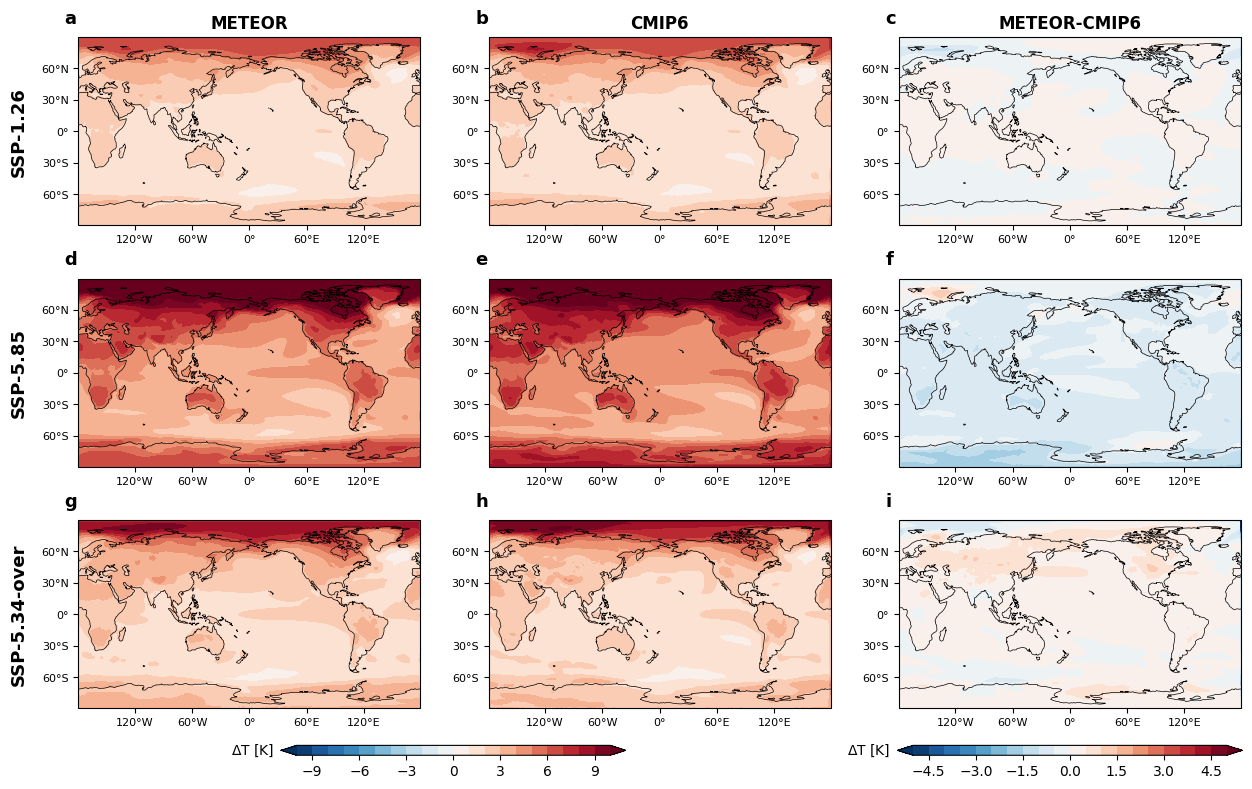

In [ ]:
var_idx = 0
levels = np.arange(-10,10.1,1)
cmap="RdBu_r"

fig = plt.figure(figsize=(15,9))
gs = GridSpec(3, 3, figure=fig)

# row 1
sub = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,0,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
#cbar_ax = fig.add_axes([0.26, 0.63, 0.23, 0.011])
#cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
sub.set_aspect(1.1)
sub.annotate('a', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-1.26', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('CMIP6', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)  
sub.annotate('b', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR-CMIP6', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,0,var_idx,:,:],0)-np.nanmean(td_ssp_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('c', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

#row 2
sub = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,3,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('d', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-5.85', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp_common_grid[var_idx,3,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1) 
sub.annotate('e', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,3,var_idx,:,:],0)-np.nanmean(td_ssp_common_grid[var_idx,3,:,:,:],0), cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('f', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

#row 3
sub = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
cbar_ax = fig.add_axes([0.26, 0.07, 0.23, 0.011])
cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
fig.text(0.241,0.071,"$\Delta$T [K]",ha="center")
sub.set_aspect(1.1)
sub.annotate('g', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-5.34-over', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('h', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[2, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0)-np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
cbar_ax = fig.add_axes([0.671, 0.07, 0.23, 0.011])
cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
fig.text(0.652,0.071,"$\Delta$T [K]",ha="center")
sub.set_aspect(1.1)
sub.annotate('i', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.2, hspace=0.15)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_spatial_tas.pdf"), bbox_inches='tight')

/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_92509/793677601.py:84: RuntimeWarning: Mean of empty slice
  cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_92509/793677601.py:108: RuntimeWarning: Mean of empty slice
  cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0)-np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())


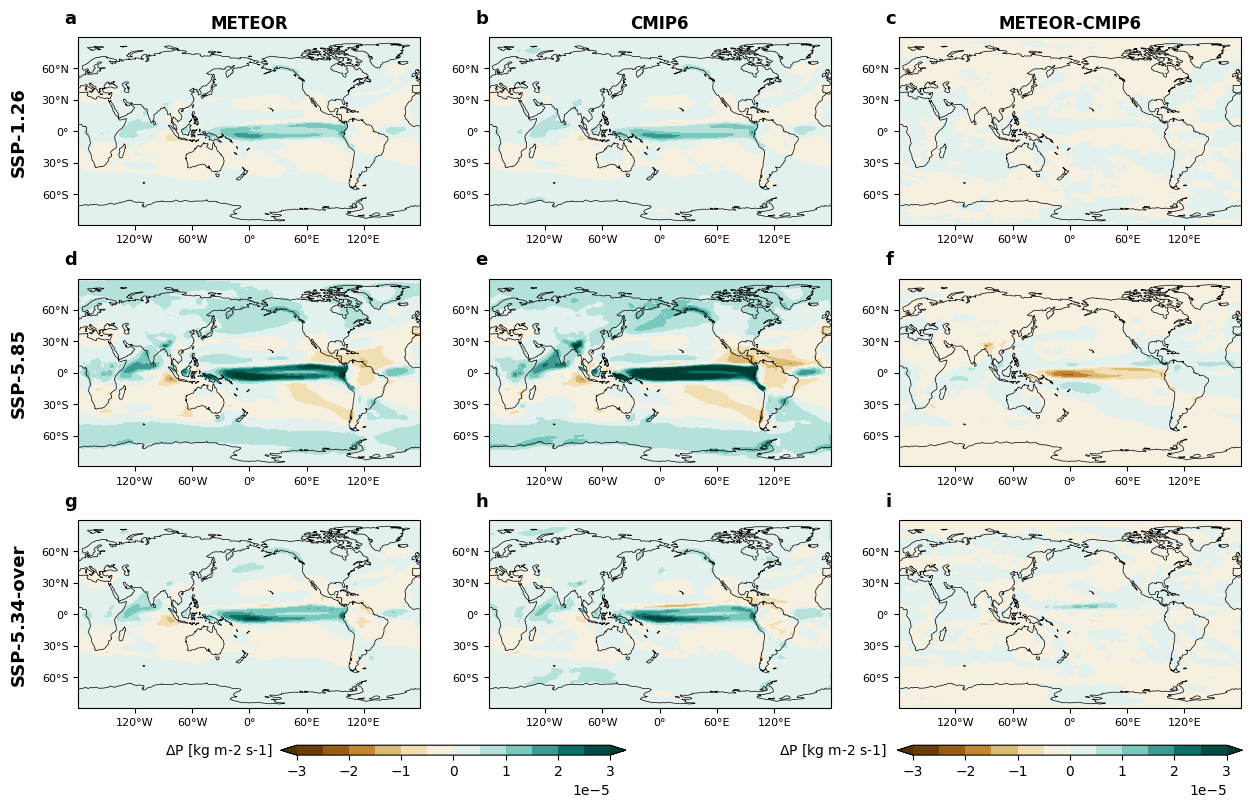

In [ ]:
var_idx = 1
levels = np.arange(-3e-5,3.1e-5,0.5e-5)
cmap="BrBG"

fig = plt.figure(figsize=(15,9))
gs = GridSpec(3, 3, figure=fig)

# row 1
sub = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,0,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
#cbar_ax = fig.add_axes([0.26, 0.63, 0.23, 0.011])
#cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
sub.set_aspect(1.1)
sub.annotate('a', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-1.26', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('CMIP6', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)  
sub.annotate('b', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR-CMIP6', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,0,var_idx,:,:],0)-np.nanmean(td_ssp_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('c', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

#row 2
sub = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,3,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('d', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-5.85', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp_common_grid[var_idx,3,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1) 
sub.annotate('e', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,3,var_idx,:,:],0)-np.nanmean(td_ssp_common_grid[var_idx,3,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('f', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

#row 3
sub = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
cbar_ax = fig.add_axes([0.26, 0.07, 0.23, 0.011])
cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
fig.text(0.219,0.071,"$\Delta$P [kg m-2 s-1]",ha="center")
sub.set_aspect(1.1)
sub.annotate('g', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-5.34-over', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('h', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[2, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0)-np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
cbar_ax = fig.add_axes([0.671, 0.07, 0.23, 0.011])
cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
fig.text(0.628,0.071,"$\Delta$P [kg m-2 s-1]",ha="center")
sub.set_aspect(1.1)
sub.annotate('i', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.2, hspace=0.15)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_spatial_pr.pdf"), bbox_inches='tight')

Pattern correlation and RMSE

In [54]:
%%capture

Pcorr = np.zeros([2,5]) * np.nan
Prmse = np.zeros([2,5]) * np.nan

for nv,var in enumerate(flds):
    for nsc,sc in enumerate(scenarios):
        if nsc == 0:
            # Standard SSPs
            array1 = np.nanmean(patterns_aer_ssp_common_grid[:,nsc,nv,:,:],0).ravel()
            array2 = np.nanmean(td_ssp_common_grid[nv,nsc,:,:,:],0).ravel()
            valid_mask = ~np.isnan(array1) & ~np.isnan(array2)     # handle NaN values
            correlation, _ = pearsonr(array1[valid_mask], array2[valid_mask])       # Pearson correlation
            Pcorr[nv,nsc] = correlation
            Prmse[nv,nsc] = np.sqrt(np.mean((array1[valid_mask] - array2[valid_mask]) ** 2))   # RMSE
            # SSP534 (and put in higher index)
            array1 = np.nanmean(patterns_aer_ssp534_common_grid[:,nsc,nv,:,:],0).ravel()
            array2 = np.nanmean(td_ssp534_common_grid[nv,nsc,:,:,:],0).ravel()
            valid_mask = ~np.isnan(array1) & ~np.isnan(array2)     # handle NaN values
            correlation, _ = pearsonr(array1[valid_mask], array2[valid_mask])       # Pearson correlation
            Pcorr[nv,nsc+4] = correlation
            Prmse[nv,nsc+4] = np.sqrt(np.mean((array1[valid_mask] - array2[valid_mask]) ** 2))   # RMSE
        else:
            # Continue with standard SSPs
            array1 = np.nanmean(patterns_aer_ssp_common_grid[:,nsc,nv,:,:],0).ravel()
            array2 = np.nanmean(td_ssp_common_grid[nv,nsc,:,:,:],0).ravel()
            valid_mask = ~np.isnan(array1) & ~np.isnan(array2)     # handle NaN values
            correlation, _ = pearsonr(array1[valid_mask], array2[valid_mask])       # Pearson correlation
            Pcorr[nv,nsc] = correlation
            Prmse[nv,nsc] = np.sqrt(np.mean((array1[valid_mask] - array2[valid_mask]) ** 2))   # RMSE


In [56]:
print('tas')
print('Pearson:', Pcorr[0,:])
print('RMSE:', Prmse[0,:])
print('pr')
print('Pearson:', Pcorr[1,:])
print('RMSE:', Prmse[1,:]*1e7)


tas
Pearson: [0.99514945 0.99843169 0.99748988 0.99483989 0.97126067]
RMSE: [0.1569598  0.17687398 0.28006307 0.73095574 0.48968831]
pr
Pearson: [0.97004501 0.99080941 0.98618904 0.96630267 0.94040799]
RMSE: [ 5.91148582  4.43923085  7.51494099 24.96742599 11.78670874]
